In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

# Project root
PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"

folders = [
    "dataset/train/input",
    "dataset/train/target",
    "dataset/val/input",
    "dataset/val/target",
    "dataset/test/input",

    "models",
    "checkpoints",
    "outputs",
    "results",
    "figures",
    "logs",

    "scripts",
    "utils"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_ROOT, folder), exist_ok=True)

print("Project folders created successfully!")
print(PROJECT_ROOT)

Project folders created successfully!
/content/drive/MyDrive/KLA_PS01


In [ ]:
!pip install -q timm albumentations lpips torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 53.0 MB/s eta 0:00:00


In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"

print("Drive Mounted:", os.path.exists("/content/drive/MyDrive"))
print("Project Exists:", os.path.exists(PROJECT_ROOT))

Drive Mounted: True
Project Exists: True


In [ ]:
import os
import zipfile

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"

TRAIN_ZIP = os.path.join(PROJECT_ROOT, "train.zip")
TEST_ZIP = os.path.join(PROJECT_ROOT, "Test_NoisyLR.zip")

TRAIN_DIR = os.path.join(PROJECT_ROOT, "dataset/train")
TEST_DIR = os.path.join(PROJECT_ROOT, "dataset/test")

os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)

# Extract only if not already extracted
if not os.path.exists(os.path.join(TRAIN_DIR, "train")):
    print("Extracting training dataset...")
    with zipfile.ZipFile(TRAIN_ZIP, 'r') as z:
        z.extractall(TRAIN_DIR)

if not os.path.exists(os.path.join(TEST_DIR, "Test_NoisyLR")):
    print("Extracting test dataset...")
    with zipfile.ZipFile(TEST_ZIP, 'r') as z:
        z.extractall(TEST_DIR)

print("Done!")

Extracting test dataset...
Done!


In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"

TRAIN_DIR = os.path.join(PROJECT_ROOT, "dataset/train")
TEST_DIR = os.path.join(PROJECT_ROOT, "dataset/test")

print("Project exists:", os.path.exists(PROJECT_ROOT))
print("Training directory:", TRAIN_DIR)
print("Training directory exists:", os.path.exists(TRAIN_DIR))
print("Test directory exists:", os.path.exists(TEST_DIR))

# Show what's inside the training directory
if os.path.exists(TRAIN_DIR):
    print("\nTraining directory contents:")
    for item in os.listdir(TRAIN_DIR):
        print("  ", item)

# Show what's inside the test directory
if os.path.exists(TEST_DIR):
    print("\nTest directory contents:")
    for item in os.listdir(TEST_DIR):
        print("  ", item)

Project exists: True
Training directory: /content/drive/MyDrive/KLA_PS01/dataset/train
Training directory exists: True
Test directory exists: True

Training directory contents:
   input
   target
   train
   __MACOSX

Test directory contents:
   input
   NoisyLR
   __MACOSX


In [ ]:
import os

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"

print("Searching for .npy files...\n")

for root, dirs, files in os.walk(os.path.join(PROJECT_ROOT, "dataset")):
    npy_files = [f for f in files if f.endswith(".npy")]

    if npy_files:
        print(f"📁 {root}")
        print(f"   Number of .npy files: {len(npy_files)}")
        print(f"   First 5 files: {npy_files[:5]}")
        print()

Searching for .npy files...

📁 /content/drive/MyDrive/KLA_PS01/dataset/train/train/GT
   Number of .npy files: 3200
   First 5 files: ['001116.npy', '000208.npy', '001670.npy', '002379.npy', '003067.npy']

📁 /content/drive/MyDrive/KLA_PS01/dataset/train/train/NoisyLR
   Number of .npy files: 3200
   First 5 files: ['001116.npy', '000208.npy', '001670.npy', '002379.npy', '003067.npy']

📁 /content/drive/MyDrive/KLA_PS01/dataset/train/__MACOSX/train/GT
   Number of .npy files: 3200
   First 5 files: ['._001116.npy', '._000208.npy', '._001670.npy', '._002379.npy', '._003067.npy']

📁 /content/drive/MyDrive/KLA_PS01/dataset/train/__MACOSX/train/NoisyLR
   Number of .npy files: 3200
   First 5 files: ['._001116.npy', '._000208.npy', '._001670.npy', '._002379.npy', '._003067.npy']

📁 /content/drive/MyDrive/KLA_PS01/dataset/test/NoisyLR
   Number of .npy files: 400
   First 5 files: ['000298.npy', '000267.npy', '000273.npy', '000065.npy', '000071.npy']

📁 /content/drive/MyDrive/KLA_PS01/dataset

GROUND TRUTH
Shape : (256, 256)
Dtype : float32
Min   : 0.0
Max   : 1.0
Mean  : 0.48987597
Std   : 0.18706687

NOISY / LOW-RESOLUTION INPUT
Shape : (128, 128)
Dtype : float32
Min   : 0.008334823
Max   : 1.4172144
Mean  : 0.49041417
Std   : 0.20591499


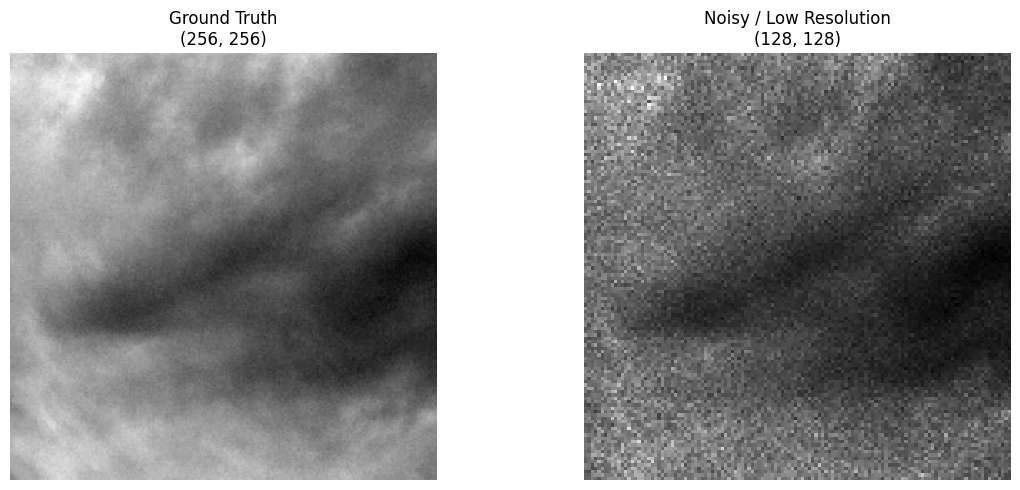

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Exact dataset paths
GT_DIR = "/content/drive/MyDrive/KLA_PS01/dataset/train/train/GT"
NOISY_DIR = "/content/drive/MyDrive/KLA_PS01/dataset/train/train/NoisyLR"

# Choose one sample
sample_name = "000208.npy"

gt_path = os.path.join(GT_DIR, sample_name)
noisy_path = os.path.join(NOISY_DIR, sample_name)

# Load NumPy arrays
gt = np.load(gt_path)
noisy = np.load(noisy_path)

# Print basic information
print("=" * 60)
print("GROUND TRUTH")
print("=" * 60)
print("Shape :", gt.shape)
print("Dtype :", gt.dtype)
print("Min   :", gt.min())
print("Max   :", gt.max())
print("Mean  :", gt.mean())
print("Std   :", gt.std())

print("\n" + "=" * 60)
print("NOISY / LOW-RESOLUTION INPUT")
print("=" * 60)
print("Shape :", noisy.shape)
print("Dtype :", noisy.dtype)
print("Min   :", noisy.min())
print("Max   :", noisy.max())
print("Mean  :", noisy.mean())
print("Std   :", noisy.std())

# Display images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(gt, cmap="gray")
axes[0].set_title(f"Ground Truth\n{gt.shape}")
axes[0].axis("off")

axes[1].imshow(noisy, cmap="gray")
axes[1].set_title(f"Noisy / Low Resolution\n{noisy.shape}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import os
import random
import numpy as np
from collections import Counter

GT_DIR = "/content/drive/MyDrive/KLA_PS01/dataset/train/train/GT"
NOISY_DIR = "/content/drive/MyDrive/KLA_PS01/dataset/train/train/NoisyLR"

# Get valid filenames from the actual GT folder
filenames = [
    f for f in os.listdir(GT_DIR)
    if f.endswith(".npy") and not f.startswith("._")
]

print(f"Total training pairs found: {len(filenames)}")

# Reproducible random sample
random.seed(42)
sample_files = random.sample(filenames, min(100, len(filenames)))

gt_shapes = Counter()
noisy_shapes = Counter()

gt_min_values = []
gt_max_values = []
gt_means = []
gt_stds = []

noisy_min_values = []
noisy_max_values = []
noisy_means = []
noisy_stds = []

missing_pairs = []

for filename in sample_files:

    gt_path = os.path.join(GT_DIR, filename)
    noisy_path = os.path.join(NOISY_DIR, filename)

    if not os.path.exists(noisy_path):
        missing_pairs.append(filename)
        continue

    gt = np.load(gt_path)
    noisy = np.load(noisy_path)

    gt_shapes[gt.shape] += 1
    noisy_shapes[noisy.shape] += 1

    gt_min_values.append(float(gt.min()))
    gt_max_values.append(float(gt.max()))
    gt_means.append(float(gt.mean()))
    gt_stds.append(float(gt.std()))

    noisy_min_values.append(float(noisy.min()))
    noisy_max_values.append(float(noisy.max()))
    noisy_means.append(float(noisy.mean()))
    noisy_stds.append(float(noisy.std()))

print("\n" + "=" * 60)
print("SHAPE ANALYSIS — 100 RANDOM TRAINING PAIRS")
print("=" * 60)

print("\nGround Truth shapes:")
for shape, count in gt_shapes.items():
    print(f"  {shape}: {count} samples")

print("\nNoisyLR shapes:")
for shape, count in noisy_shapes.items():
    print(f"  {shape}: {count} samples")

print("\n" + "=" * 60)
print("GROUND TRUTH STATISTICS")
print("=" * 60)

print(f"Minimum value observed : {min(gt_min_values):.6f}")
print(f"Maximum value observed : {max(gt_max_values):.6f}")
print(f"Mean of image means    : {np.mean(gt_means):.6f}")
print(f"Mean of image stds     : {np.mean(gt_stds):.6f}")

print("\n" + "=" * 60)
print("NOISYLR STATISTICS")
print("=" * 60)

print(f"Minimum value observed : {min(noisy_min_values):.6f}")
print(f"Maximum value observed : {max(noisy_max_values):.6f}")
print(f"Mean of image means    : {np.mean(noisy_means):.6f}")
print(f"Mean of image stds     : {np.mean(noisy_stds):.6f}")

# Count how many sampled noisy images exceed 1
exceed_one = sum(1 for x in noisy_max_values if x > 1.0)

print("\n" + "=" * 60)
print("OUT-OF-RANGE CHECK")
print("=" * 60)

print(
    f"NoisyLR samples with max > 1.0: "
    f"{exceed_one}/{len(noisy_max_values)}"
)

print(
    f"Highest NoisyLR value observed: "
    f"{max(noisy_max_values):.6f}"
)

print("\nMissing GT/NoisyLR pairs:", len(missing_pairs))

Total training pairs found: 3200

SHAPE ANALYSIS — 100 RANDOM TRAINING PAIRS

Ground Truth shapes:
  (256, 256): 100 samples

NoisyLR shapes:
  (128, 128): 100 samples

GROUND TRUTH STATISTICS
Minimum value observed : 0.000000
Maximum value observed : 1.000000
Mean of image means    : 0.442848
Mean of image stds     : 0.188098

NOISYLR STATISTICS
Minimum value observed : -0.276927
Maximum value observed : 1.849679
Mean of image means    : 0.442928
Mean of image stds     : 0.206771

OUT-OF-RANGE CHECK
NoisyLR samples with max > 1.0: 99/100
Highest NoisyLR value observed: 1.849679

Missing GT/NoisyLR pairs: 0


In [ ]:
import os
import numpy as np
import time

GT_DIR = "/content/drive/MyDrive/KLA_PS01/dataset/train/train/GT"
NOISY_DIR = "/content/drive/MyDrive/KLA_PS01/dataset/train/train/NoisyLR"

filenames = sorted([
    f for f in os.listdir(GT_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

print(f"Analyzing {len(filenames)} training pairs...")
print("This may take a little while because we are reading all images once.")

start_time = time.time()

# Running statistics
gt_sum = 0.0
gt_sum_sq = 0.0
gt_count = 0

noisy_sum = 0.0
noisy_sum_sq = 0.0
noisy_count = 0

gt_min = np.inf
gt_max = -np.inf

noisy_min = np.inf
noisy_max = -np.inf

noisy_above_1 = 0
noisy_below_0 = 0

for i, filename in enumerate(filenames):

    gt = np.load(os.path.join(GT_DIR, filename))
    noisy = np.load(os.path.join(NOISY_DIR, filename))

    # Ground Truth
    gt64 = gt.astype(np.float64)
    gt_sum += gt64.sum()
    gt_sum_sq += np.square(gt64).sum()
    gt_count += gt64.size

    gt_min = min(gt_min, float(gt.min()))
    gt_max = max(gt_max, float(gt.max()))

    # NoisyLR
    noisy64 = noisy.astype(np.float64)
    noisy_sum += noisy64.sum()
    noisy_sum_sq += np.square(noisy64).sum()
    noisy_count += noisy64.size

    noisy_min = min(noisy_min, float(noisy.min()))
    noisy_max = max(noisy_max, float(noisy.max()))

    noisy_above_1 += int(np.sum(noisy > 1.0))
    noisy_below_0 += int(np.sum(noisy < 0.0))

    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{len(filenames)}")

# Calculate exact means and standard deviations
gt_mean = gt_sum / gt_count
gt_var = (gt_sum_sq / gt_count) - (gt_mean ** 2)
gt_std = np.sqrt(max(gt_var, 0))

noisy_mean = noisy_sum / noisy_count
noisy_var = (noisy_sum_sq / noisy_count) - (noisy_mean ** 2)
noisy_std = np.sqrt(max(noisy_var, 0))

elapsed = time.time() - start_time

print("\n" + "=" * 65)
print("EXACT DATASET STATISTICS")
print("=" * 65)

print("\nGROUND TRUTH")
print(f"  Total pixels : {gt_count:,}")
print(f"  Min         : {gt_min:.6f}")
print(f"  Max         : {gt_max:.6f}")
print(f"  Mean        : {gt_mean:.6f}")
print(f"  Std         : {gt_std:.6f}")

print("\nNOISYLR")
print(f"  Total pixels : {noisy_count:,}")
print(f"  Min         : {noisy_min:.6f}")
print(f"  Max         : {noisy_max:.6f}")
print(f"  Mean        : {noisy_mean:.6f}")
print(f"  Std         : {noisy_std:.6f}")

print("\nOUT-OF-RANGE PIXELS")
print(f"  Pixels > 1  : {noisy_above_1:,}")
print(f"  Pixels < 0  : {noisy_below_0:,}")

print("\nProcessing time:")
print(f"  {elapsed:.2f} seconds")

# Save statistics for later use
DATASET_STATS = {
    "gt_mean": gt_mean,
    "gt_std": gt_std,
    "gt_min": gt_min,
    "gt_max": gt_max,
    "noisy_mean": noisy_mean,
    "noisy_std": noisy_std,
    "noisy_min": noisy_min,
    "noisy_max": noisy_max,
}

print("\nStatistics stored in DATASET_STATS.")

Analyzing 3200 training pairs...
This may take a little while because we are reading all images once.
Processed 500/3200
Processed 1000/3200
Processed 1500/3200
Processed 2000/3200
Processed 2500/3200
Processed 3000/3200

EXACT DATASET STATISTICS

GROUND TRUTH
  Total pixels : 209,715,200
  Min         : 0.000000
  Max         : 1.000000
  Mean        : 0.433528
  Std         : 0.272646

NOISYLR
  Total pixels : 52,428,800
  Min         : -0.278563
  Max         : 2.158005
  Mean        : 0.433536
  Std         : 0.284787

OUT-OF-RANGE PIXELS
  Pixels > 1  : 1,629,724
  Pixels < 0  : 149,367

Processing time:
  2000.69 seconds

Statistics stored in DATASET_STATS.


In [ ]:
import os
import shutil
import time

DRIVE_ROOT = "/content/drive/MyDrive/KLA_PS01/dataset"

LOCAL_ROOT = "/content/KLA_PS01_dataset"

start_time = time.time()

# Remove old local copy if one exists
if os.path.exists(LOCAL_ROOT):
    shutil.rmtree(LOCAL_ROOT)

print("Copying dataset from Google Drive to Colab local storage...")
print("Please wait — this should be much faster than repeatedly reading from Drive.")

shutil.copytree(DRIVE_ROOT, LOCAL_ROOT)

elapsed = time.time() - start_time

print("\nDataset copied successfully!")
print(f"Local dataset: {LOCAL_ROOT}")
print(f"Copy time: {elapsed:.2f} seconds")

# Verify
GT_DIR = os.path.join(
    LOCAL_ROOT, "train", "train", "GT"
)

NOISY_DIR = os.path.join(
    LOCAL_ROOT, "train", "train", "NoisyLR"
)

TEST_DIR = os.path.join(
    LOCAL_ROOT, "test", "NoisyLR"
)

gt_count = len([
    f for f in os.listdir(GT_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

noisy_count = len([
    f for f in os.listdir(NOISY_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

test_count = len([
    f for f in os.listdir(TEST_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

print("\nVerification:")
print("GT images     :", gt_count)
print("NoisyLR images:", noisy_count)
print("Test images   :", test_count)

Copying dataset from Google Drive to Colab local storage...
Please wait — this should be much faster than repeatedly reading from Drive.

Dataset copied successfully!
Local dataset: /content/KLA_PS01_dataset
Copy time: 169.92 seconds

Verification:
GT images     : 3200
NoisyLR images: 3200
Test images   : 400


In [ ]:
import torch

print("=" * 60)
print("GPU CHECK")
print("=" * 60)

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name        :", torch.cuda.get_device_name(0))
    print("GPU count       :", torch.cuda.device_count())

    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU memory      : {gpu_memory:.2f} GB")

    print("\n✅ T4 GPU is ready for model training.")
else:
    print("\n❌ CUDA is not available.")

GPU CHECK
PyTorch version : 2.11.0+cu128
CUDA available  : True
GPU name        : Tesla T4
GPU count       : 1
GPU memory      : 14.56 GB

✅ T4 GPU is ready for model training.


In [ ]:
# ============================================================
# TRAIN / VALIDATION SPLIT + PYTORCH DATASET
# ============================================================

import os
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

LOCAL_ROOT = "/content/KLA_PS01_dataset"

GT_DIR = os.path.join(
    LOCAL_ROOT, "train", "train", "GT"
)

NOISY_DIR = os.path.join(
    LOCAL_ROOT, "train", "train", "NoisyLR"
)

# ------------------------------------------------------------
# Get valid paired filenames
# ------------------------------------------------------------

filenames = sorted([
    f for f in os.listdir(GT_DIR)
    if f.endswith(".npy") and not f.startswith("._")
])

# Make sure every GT has a corresponding NoisyLR
paired_filenames = [
    f for f in filenames
    if os.path.exists(os.path.join(NOISY_DIR, f))
]

print("Total paired samples:", len(paired_filenames))

# ------------------------------------------------------------
# Reproducible train/validation split
# ------------------------------------------------------------

random.seed(42)

shuffled = paired_filenames.copy()
random.shuffle(shuffled)

split_index = int(0.90 * len(shuffled))

train_files = shuffled[:split_index]
val_files = shuffled[split_index:]

print("Training samples  :", len(train_files))
print("Validation samples:", len(val_files))

# ------------------------------------------------------------
# Dataset
# ------------------------------------------------------------

class WaferRestorationDataset(Dataset):

    def __init__(self, filenames, gt_dir, noisy_dir, augment=False):
        self.filenames = filenames
        self.gt_dir = gt_dir
        self.noisy_dir = noisy_dir
        self.augment = augment

        # Statistics obtained from the complete training dataset
        self.noisy_mean = 0.433536
        self.noisy_std = 0.284787

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):

        filename = self.filenames[idx]

        # Load paired arrays
        noisy = np.load(
            os.path.join(self.noisy_dir, filename)
        ).astype(np.float32)

        gt = np.load(
            os.path.join(self.gt_dir, filename)
        ).astype(np.float32)

        # ----------------------------------------------------
        # Paired spatial augmentation
        # ----------------------------------------------------
        if self.augment:

            # Random horizontal flip
            if random.random() < 0.5:
                noisy = np.fliplr(noisy).copy()
                gt = np.fliplr(gt).copy()

            # Random vertical flip
            if random.random() < 0.5:
                noisy = np.flipud(noisy).copy()
                gt = np.flipud(gt).copy()

            # Random 90-degree rotation
            k = random.randint(0, 3)

            if k > 0:
                noisy = np.rot90(noisy, k).copy()
                gt = np.rot90(gt, k).copy()

        # ----------------------------------------------------
        # Normalize input
        #
        # IMPORTANT:
        # We do NOT clip the noisy image to [0,1].
        # The challenge data contains values below 0 and
        # above 1.
        # ----------------------------------------------------

        noisy = (noisy - self.noisy_mean) / self.noisy_std

        # Convert H,W → C,H,W
        noisy = torch.from_numpy(noisy).unsqueeze(0)
        gt = torch.from_numpy(gt).unsqueeze(0)

        return noisy, gt, filename


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = WaferRestorationDataset(
    train_files,
    GT_DIR,
    NOISY_DIR,
    augment=True
)

val_dataset = WaferRestorationDataset(
    val_files,
    GT_DIR,
    NOISY_DIR,
    augment=False
)

print("\nDatasets created successfully.")
print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))

Total paired samples: 3200
Training samples  : 2880
Validation samples: 320

Datasets created successfully.
Train dataset: 2880
Val dataset  : 320


In [ ]:
# ============================================================
# DATALOADERS + GPU BATCH TEST
# ============================================================

from torch.utils.data import DataLoader

# ------------------------------------------------------------
# DataLoader configuration
# ------------------------------------------------------------

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

print("DataLoaders created.")
print("Batch size:", BATCH_SIZE)
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))


# ------------------------------------------------------------
# Get one batch
# ------------------------------------------------------------

noisy_batch, gt_batch, filenames_batch = next(iter(train_loader))

print("\n" + "=" * 60)
print("CPU BATCH")
print("=" * 60)

print("NoisyLR batch shape :", noisy_batch.shape)
print("GT batch shape     :", gt_batch.shape)
print("NoisyLR dtype      :", noisy_batch.dtype)
print("GT dtype           :", gt_batch.dtype)

# ------------------------------------------------------------
# Move batch to T4
# ------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

noisy_gpu = noisy_batch.to(device, non_blocking=True)
gt_gpu = gt_batch.to(device, non_blocking=True)

print("\n" + "=" * 60)
print("GPU BATCH")
print("=" * 60)

print("Device:", device)
print("NoisyLR device:", noisy_gpu.device)
print("GT device     :", gt_gpu.device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

print("\n✅ DataLoader → T4 GPU test successful.")

DataLoaders created.
Batch size: 8
Training batches: 360
Validation batches: 40

CPU BATCH
NoisyLR batch shape : torch.Size([8, 1, 128, 128])
GT batch shape     : torch.Size([8, 1, 256, 256])
NoisyLR dtype      : torch.float32
GT dtype           : torch.float32

GPU BATCH
Device: cuda
NoisyLR device: cuda:0
GT device     : cuda:0
GPU name: Tesla T4

✅ DataLoader → T4 GPU test successful.


In [ ]:
# ============================================================
# KLA PS01 — RESIDUAL U-NET SUPER-RESOLUTION MODEL
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------------------------------------
# Residual Block
# ------------------------------------------------------------

class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv1 = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            num_groups=8,
            num_channels=channels
        )

        self.conv2 = nn.Conv2d(
            channels, channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            num_groups=8,
            num_channels=channels
        )

        self.activation = nn.GELU()

    def forward(self, x):

        residual = x

        x = self.conv1(x)
        x = self.norm1(x)
        x = self.activation(x)

        x = self.conv2(x)
        x = self.norm2(x)

        return self.activation(x + residual)


# ------------------------------------------------------------
# Channel Attention
# ------------------------------------------------------------

class ChannelAttention(nn.Module):

    def __init__(self, channels, reduction=8):
        super().__init__()

        hidden = max(channels // reduction, 4)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, 1),
            nn.GELU(),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):

        attention = self.pool(x)
        attention = self.fc(attention)

        return x * attention


# ------------------------------------------------------------
# Residual Attention Block
# ------------------------------------------------------------

class ResidualAttentionBlock(nn.Module):

    def __init__(self, channels):
        super().__init__()

        self.residual = ResidualBlock(channels)
        self.attention = ChannelAttention(channels)

    def forward(self, x):

        x = self.residual(x)
        x = self.attention(x)

        return x


# ------------------------------------------------------------
# Downsampling Block
# ------------------------------------------------------------

class DownBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=2,
                padding=1
            ),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),

            ResidualAttentionBlock(out_channels)
        )

    def forward(self, x):
        return self.block(x)


# ------------------------------------------------------------
# Upsampling Block
# ------------------------------------------------------------

class UpBlock(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.fuse = nn.Sequential(
            nn.Conv2d(
                out_channels * 2,
                out_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GroupNorm(8, out_channels),
            nn.GELU(),

            ResidualAttentionBlock(out_channels)
        )

    def forward(self, x, skip):

        x = self.up(x)

        # Safety for possible spatial mismatch
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(
                x,
                size=skip.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([x, skip], dim=1)

        return self.fuse(x)


# ------------------------------------------------------------
# Complete Restoration Network
# ------------------------------------------------------------

class KLAResUNet(nn.Module):

    def __init__(self, base_channels=32):

        super().__init__()

        # Input: 1 × 128 × 128

        self.input_conv = nn.Sequential(
            nn.Conv2d(
                1,
                base_channels,
                kernel_size=3,
                padding=1
            ),
            nn.GELU()
        )

        # Encoder
        self.enc1 = nn.Sequential(
            ResidualAttentionBlock(base_channels),
            ResidualAttentionBlock(base_channels)
        )

        self.down1 = DownBlock(
            base_channels,
            base_channels * 2
        )

        self.enc2 = nn.Sequential(
            ResidualAttentionBlock(base_channels * 2),
            ResidualAttentionBlock(base_channels * 2)
        )

        self.down2 = DownBlock(
            base_channels * 2,
            base_channels * 4
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            ResidualAttentionBlock(base_channels * 4),
            ResidualAttentionBlock(base_channels * 4),
            ResidualAttentionBlock(base_channels * 4)
        )

        # Decoder
        self.up2 = UpBlock(
            base_channels * 4,
            base_channels * 2
        )

        self.up1 = UpBlock(
            base_channels * 2,
            base_channels
        )

        # ----------------------------------------------------
        # Super-resolution head
        # ----------------------------------------------------

        self.pre_sr = nn.Sequential(
            nn.Conv2d(
                base_channels,
                base_channels * 4,
                kernel_size=3,
                padding=1
            ),
            nn.GELU()
        )

        self.pixel_shuffle = nn.PixelShuffle(2)

        self.output_conv = nn.Conv2d(
            base_channels,
            1,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):

        # Encoder
        x0 = self.input_conv(x)

        e1 = self.enc1(x0)

        e2 = self.down1(e1)
        e2 = self.enc2(e2)

        b = self.down2(e2)
        b = self.bottleneck(b)

        # Decoder
        d2 = self.up2(b, e2)
        d1 = self.up1(d2, e1)

        # 2× Super-resolution
        x = self.pre_sr(d1)
        x = self.pixel_shuffle(x)

        # Output
        x = self.output_conv(x)

        # Ground truth is [0,1].
        # Constrain final prediction to [0,1].
        x = torch.sigmoid(x)

        return x


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = KLAResUNet(base_channels=32).to(device)


# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("=" * 60)
print("KLA RESTORATION MODEL")
print("=" * 60)

print("Device           :", device)
print("Total parameters :", f"{total_params:,}")
print("Trainable params :", f"{trainable_params:,}")

# ------------------------------------------------------------
# Test forward pass
# ------------------------------------------------------------

with torch.no_grad():

    test_input = noisy_gpu[:2]

    test_output = model(test_input)

print("\nForward pass test:")
print("Input shape :", test_input.shape)
print("Output shape:", test_output.shape)
print("Output min  :", test_output.min().item())
print("Output max  :", test_output.max().item())

print("\n✅ Model forward pass successful.")

KLA RESTORATION MODEL
Device           : cuda
Total parameters : 1,821,101
Trainable params : 1,821,101

Forward pass test:
Input shape : torch.Size([2, 1, 128, 128])
Output shape: torch.Size([2, 1, 256, 256])
Output min  : 0.35329142212867737
Output max  : 0.6372952461242676

✅ Model forward pass successful.


In [ ]:
# ============================================================
# KLA PS01 — RESTORATION LOSS FUNCTIONS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ------------------------------------------------------------
# SSIM Loss
# ------------------------------------------------------------

def gaussian_window(window_size=11, sigma=1.5, device="cpu"):
    coords = torch.arange(
        window_size,
        dtype=torch.float32,
        device=device
    )

    coords -= window_size // 2

    gaussian = torch.exp(
        -(coords ** 2) / (2 * sigma ** 2)
    )

    gaussian /= gaussian.sum()

    window = gaussian[:, None] * gaussian[None, :]

    return window.unsqueeze(0).unsqueeze(0)


def ssim_loss(pred, target, window_size=11):

    device = pred.device

    window = gaussian_window(
        window_size=window_size,
        sigma=1.5,
        device=device
    )

    # Expand for single-channel images
    window = window.expand(
        pred.size(1),
        1,
        window_size,
        window_size
    )

    mu_pred = F.conv2d(
        pred,
        window,
        padding=window_size // 2,
        groups=pred.size(1)
    )

    mu_target = F.conv2d(
        target,
        window,
        padding=window_size // 2,
        groups=target.size(1)
    )

    mu_pred_sq = mu_pred ** 2
    mu_target_sq = mu_target ** 2
    mu_pred_target = mu_pred * mu_target

    sigma_pred = (
        F.conv2d(
            pred ** 2,
            window,
            padding=window_size // 2,
            groups=pred.size(1)
        )
        - mu_pred_sq
    )

    sigma_target = (
        F.conv2d(
            target ** 2,
            window,
            padding=window_size // 2,
            groups=target.size(1)
        )
        - mu_target_sq
    )

    sigma_pred_target = (
        F.conv2d(
            pred * target,
            window,
            padding=window_size // 2,
            groups=pred.size(1)
        )
        - mu_pred_target
    )

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    ssim_map = (
        (2 * mu_pred_target + C1)
        * (2 * sigma_pred_target + C2)
    ) / (
        (mu_pred_sq + mu_target_sq + C1)
        * (sigma_pred + sigma_target + C2)
    )

    return 1.0 - ssim_map.mean()


# ------------------------------------------------------------
# Sobel Edge Loss
# ------------------------------------------------------------

class EdgeLoss(nn.Module):

    def __init__(self):
        super().__init__()

        sobel_x = torch.tensor(
            [
                [-1, 0, 1],
                [-2, 0, 2],
                [-1, 0, 1]
            ],
            dtype=torch.float32
        )

        sobel_y = torch.tensor(
            [
                [-1, -2, -1],
                [ 0,  0,  0],
                [ 1,  2,  1]
            ],
            dtype=torch.float32
        )

        self.register_buffer(
            "sobel_x",
            sobel_x.view(1, 1, 3, 3)
        )

        self.register_buffer(
            "sobel_y",
            sobel_y.view(1, 1, 3, 3)
        )

    def forward(self, pred, target):

        pred_x = F.conv2d(
            pred,
            self.sobel_x,
            padding=1
        )

        pred_y = F.conv2d(
            pred,
            self.sobel_y,
            padding=1
        )

        target_x = F.conv2d(
            target,
            self.sobel_x,
            padding=1
        )

        target_y = F.conv2d(
            target,
            self.sobel_y,
            padding=1
        )

        pred_edges = torch.sqrt(
            pred_x ** 2 +
            pred_y ** 2 +
            1e-6
        )

        target_edges = torch.sqrt(
            target_x ** 2 +
            target_y ** 2 +
            1e-6
        )

        return F.l1_loss(
            pred_edges,
            target_edges
        )


# ------------------------------------------------------------
# Combined Restoration Loss
# ------------------------------------------------------------

class RestorationLoss(nn.Module):

    def __init__(
        self,
        l1_weight=0.6,
        ssim_weight=0.25,
        edge_weight=0.15
    ):
        super().__init__()

        self.l1_weight = l1_weight
        self.ssim_weight = ssim_weight
        self.edge_weight = edge_weight

        self.edge_loss = EdgeLoss()

    def forward(self, pred, target):

        l1 = F.l1_loss(pred, target)

        ssim = ssim_loss(
            pred,
            target
        )

        edge = self.edge_loss(
            pred,
            target
        )

        total = (
            self.l1_weight * l1
            + self.ssim_weight * ssim
            + self.edge_weight * edge
        )

        return total, {
            "l1": l1.detach().item(),
            "ssim": ssim.detach().item(),
            "edge": edge.detach().item()
        }


# ------------------------------------------------------------
# Create loss function
# ------------------------------------------------------------

criterion = RestorationLoss().to(device)

print("=" * 60)
print("RESTORATION LOSS")
print("=" * 60)

print("L1 weight   : 0.60")
print("SSIM weight : 0.25")
print("Edge weight : 0.15")

# ------------------------------------------------------------
# Test loss
# ------------------------------------------------------------

with torch.no_grad():

    test_pred = model(noisy_gpu[:2])
    test_target = gt_gpu[:2]

test_loss, loss_components = criterion(
    test_pred,
    test_target
)

print("\nInitial untrained loss:", test_loss.item())
print("Components:", loss_components)

print("\n✅ Loss function test successful.")

RESTORATION LOSS
L1 weight   : 0.60
SSIM weight : 0.25
Edge weight : 0.15

Initial untrained loss: 0.26186805963516235
Components: {'l1': 0.12653116881847382, 'ssim': 0.5949819684028625, 'edge': 0.24802570044994354}

✅ Loss function test successful.


In [ ]:
# ============================================================
# KLA PS01 — TRAINING CONFIGURATION
# ============================================================

import os
import math
import time
import numpy as np
import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

NUM_EPOCHS = 30

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

GRAD_CLIP = 1.0

# Save checkpoints to Google Drive
CHECKPOINT_DIR = "/content/drive/MyDrive/KLA_PS01/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "kla_resunet_best.pt"
)

LAST_MODEL_PATH = os.path.join(
    CHECKPOINT_DIR,
    "kla_resunet_last.pt"
)

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Learning-rate scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-6
)

# ------------------------------------------------------------
# Mixed precision
# ------------------------------------------------------------

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

# ------------------------------------------------------------
# PSNR
# ------------------------------------------------------------

def calculate_psnr(pred, target):

    mse = F.mse_loss(
        pred,
        target
    ).item()

    if mse == 0:
        return 100.0

    return 10.0 * math.log10(
        1.0 / mse
    )


# ------------------------------------------------------------
# Training configuration summary
# ------------------------------------------------------------

print("=" * 60)
print("TRAINING CONFIGURATION")
print("=" * 60)

print(f"Epochs          : {NUM_EPOCHS}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Weight decay    : {WEIGHT_DECAY}")
print(f"Gradient clip   : {GRAD_CLIP}")
print("Optimizer       : AdamW")
print("Scheduler       : CosineAnnealingLR")
print("Mixed precision : Enabled")
print("Device          :", device)

print("\nCheckpoint:")
print(BEST_MODEL_PATH)

print("\n✅ Training configuration ready.")

TRAINING CONFIGURATION
Epochs          : 30
Batch size      : 8
Learning rate   : 0.0001
Weight decay    : 0.0001
Gradient clip   : 1.0
Optimizer       : AdamW
Scheduler       : CosineAnnealingLR
Mixed precision : Enabled
Device          : cuda

Checkpoint:
/content/drive/MyDrive/KLA_PS01/checkpoints/kla_resunet_best.pt

✅ Training configuration ready.


In [ ]:
# ============================================================
# KLA PS01 — TRAINING LOOP
# ============================================================

import time
import numpy as np
import torch
import torch.nn.functional as F

# ------------------------------------------------------------
# Training history
# ------------------------------------------------------------

history = {
    "train_loss": [],
    "val_loss": [],
    "val_psnr": [],
    "learning_rate": [],
    "epoch_time": []
}

best_val_loss = float("inf")
epochs_without_improvement = 0

PATIENCE = 7

print("=" * 70)
print("STARTING KLA IMAGE RESTORATION TRAINING")
print("=" * 70)

print(f"Epochs       : {NUM_EPOCHS}")
print(f"Batch size   : {BATCH_SIZE}")
print(f"Train images : {len(train_dataset)}")
print(f"Val images   : {len(val_dataset)}")
print(f"Device       : {device}")
print(f"Model params : {total_params:,}")

print("\nTraining started...\n")


# ============================================================
# EPOCH LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    epoch_start = time.time()

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    model.train()

    train_loss_total = 0.0

    for batch_idx, (noisy, target, filenames) in enumerate(train_loader):

        noisy = noisy.to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Mixed precision
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=torch.cuda.is_available()
        ):

            prediction = model(noisy)

            loss, loss_components = criterion(
                prediction,
                target
            )

        # Backpropagation
        scaler.scale(loss).backward()

        # Gradient clipping
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        scaler.step(optimizer)
        scaler.update()

        train_loss_total += loss.item()

    train_loss = (
        train_loss_total /
        len(train_loader)
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_loss_total = 0.0
    val_psnr_total = 0.0

    with torch.no_grad():

        for noisy, target, filenames in val_loader:

            noisy = noisy.to(
                device,
                non_blocking=True
            )

            target = target.to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=torch.cuda.is_available()
            ):

                prediction = model(noisy)

                val_loss, _ = criterion(
                    prediction,
                    target
                )

            val_loss_total += val_loss.item()

            # PSNR calculation
            mse = F.mse_loss(
                prediction.float(),
                target.float()
            ).item()

            if mse > 0:
                psnr = 10.0 * np.log10(
                    1.0 / mse
                )
            else:
                psnr = 100.0

            val_psnr_total += psnr

    val_loss = (
        val_loss_total /
        len(val_loader)
    )

    val_psnr = (
        val_psnr_total /
        len(val_loader)
    )


    # --------------------------------------------------------
    # Scheduler
    # --------------------------------------------------------

    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = time.time() - epoch_start


    # --------------------------------------------------------
    # Save history
    # --------------------------------------------------------

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_psnr"].append(
        val_psnr
    )

    history["learning_rate"].append(
        current_lr
    )

    history["epoch_time"].append(
        epoch_time
    )


    # --------------------------------------------------------
    # Save best model
    # --------------------------------------------------------

    improved = val_loss < best_val_loss

    if improved:

        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_loss": val_loss,
                "val_psnr": val_psnr,
                "history": history
            },
            BEST_MODEL_PATH
        )

        best_marker = " ⭐ BEST"

    else:

        epochs_without_improvement += 1
        best_marker = ""


    # --------------------------------------------------------
    # Save last checkpoint
    # --------------------------------------------------------

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "val_loss": val_loss,
            "val_psnr": val_psnr,
            "history": history
        },
        LAST_MODEL_PATH
    )


    # --------------------------------------------------------
    # Print epoch results
    # --------------------------------------------------------

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {val_loss:.5f} | "
        f"PSNR: {val_psnr:.2f} dB | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )


    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print(
            f"\nEarly stopping triggered after "
            f"{PATIENCE} epochs without improvement."
        )

        break


print("\n" + "=" * 70)
print("TRAINING FINISHED")
print("=" * 70)

print(f"Best validation loss : {best_val_loss:.6f}")

print(
    f"Best model saved to:\n"
    f"{BEST_MODEL_PATH}"
)

print(
    f"\nLast checkpoint saved to:\n"
    f"{LAST_MODEL_PATH}"
)

STARTING KLA IMAGE RESTORATION TRAINING
Epochs       : 30
Batch size   : 8
Train images : 2880
Val images   : 320
Device       : cuda
Model params : 1,821,101

Training started...

Epoch [01/30] | Train Loss: 0.19493 | Val Loss: 0.16425 | PSNR: 19.09 dB | LR: 9.97e-05 | Time: 29.5s ⭐ BEST
Epoch [02/30] | Train Loss: 0.15106 | Val Loss: 0.13577 | PSNR: 22.28 dB | LR: 9.89e-05 | Time: 28.3s ⭐ BEST
Epoch [03/30] | Train Loss: 0.14679 | Val Loss: 0.15368 | PSNR: 18.45 dB | LR: 9.76e-05 | Time: 28.2s
Epoch [04/30] | Train Loss: 0.13262 | Val Loss: 0.12816 | PSNR: 23.45 dB | LR: 9.57e-05 | Time: 28.2s ⭐ BEST
Epoch [05/30] | Train Loss: 0.13062 | Val Loss: 0.13327 | PSNR: 21.07 dB | LR: 9.34e-05 | Time: 28.1s
Epoch [06/30] | Train Loss: 0.12956 | Val Loss: 0.12493 | PSNR: 22.16 dB | LR: 9.05e-05 | Time: 27.9s ⭐ BEST
Epoch [07/30] | Train Loss: 0.12700 | Val Loss: 0.12663 | PSNR: 21.64 dB | LR: 8.73e-05 | Time: 28.0s
Epoch [08/30] | Train Loss: 0.12434 | Val Loss: 0.12806 | PSNR: 20.96 dB | LR

BEST VALIDATION EXAMPLE
Input shape     : (128, 128)
Prediction shape: (256, 256)
Target shape    : (256, 256)


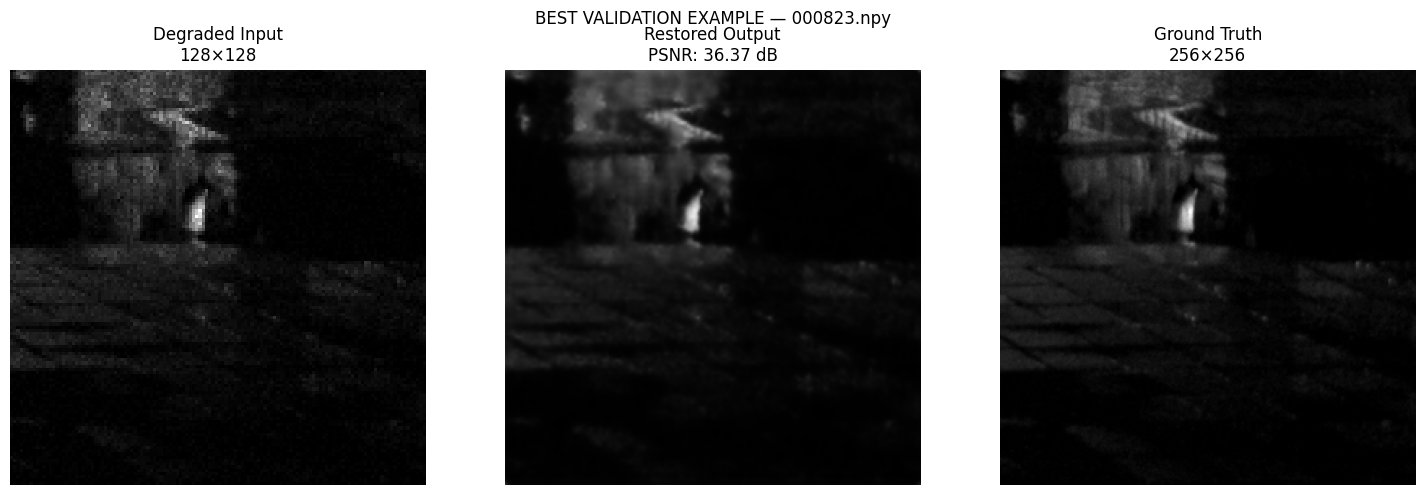


WORST VALIDATION EXAMPLE
Input shape     : (128, 128)
Prediction shape: (256, 256)
Target shape    : (256, 256)


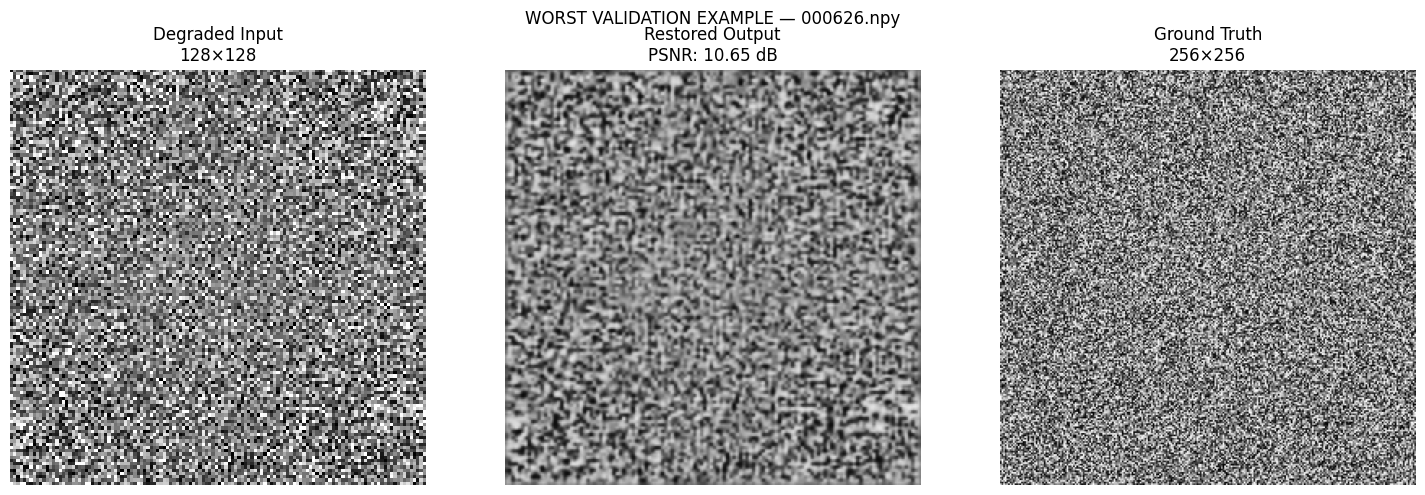

In [ ]:
# ============================================================
# ROBUST VALIDATION VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np


def to_image_2d(array):
    """
    Convert either:
        (H, W)
        (1, H, W)
        (H, W, 1)
    into:
        (H, W)
    """

    array = np.asarray(array)

    # Remove dimensions of size 1
    array = np.squeeze(array)

    if array.ndim != 2:
        raise ValueError(
            f"Expected a 2D image after squeezing, "
            f"but got shape {array.shape}"
        )

    return array


def display_example(example, title):

    # --------------------------------------------------------
    # Convert all images safely to 2D
    # --------------------------------------------------------

    input_img = to_image_2d(
        example["input"]
    )

    prediction = to_image_2d(
        example["prediction"]
    )

    target = to_image_2d(
        example["target"]
    )

    # --------------------------------------------------------
    # Print shapes for verification
    # --------------------------------------------------------

    print("Input shape     :", input_img.shape)
    print("Prediction shape:", prediction.shape)
    print("Target shape    :", target.shape)

    # --------------------------------------------------------
    # Undo input normalization
    # --------------------------------------------------------

    input_img = (
        input_img * 0.284787
        + 0.433536
    )

    # Visualization clipping only
    input_display = np.clip(
        input_img,
        0,
        1
    )

    prediction_display = np.clip(
        prediction,
        0,
        1
    )

    target_display = np.clip(
        target,
        0,
        1
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(
        input_display,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0].set_title(
        "Degraded Input\n128×128"
    )

    axes[1].imshow(
        prediction_display,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        f"Restored Output\n"
        f"PSNR: {example['psnr']:.2f} dB"
    )

    axes[2].imshow(
        target_display,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[2].set_title(
        "Ground Truth\n256×256"
    )

    for ax in axes:
        ax.axis("off")

    plt.suptitle(
        f"{title} — {example['filename']}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# BEST CASE
# ============================================================

print("=" * 60)
print("BEST VALIDATION EXAMPLE")
print("=" * 60)

display_example(
    best_examples[0],
    "BEST VALIDATION EXAMPLE"
)


# ============================================================
# WORST CASE
# ============================================================

print("\n" + "=" * 60)
print("WORST VALIDATION EXAMPLE")
print("=" * 60)

display_example(
    worst_examples[0],
    "WORST VALIDATION EXAMPLE"
)

In [ ]:
# ============================================================
# KLA PS01 — SSIM + LPIPS EVALUATION
# ============================================================

# Install LPIPS if necessary
!pip install -q lpips scikit-image

import numpy as np
import torch
import torch.nn.functional as F

from skimage.metrics import structural_similarity
import lpips


# ============================================================
# LPIPS MODEL
# ============================================================

lpips_model = lpips.LPIPS(
    net='alex'
).to(device)

lpips_model.eval()

print("LPIPS model loaded.")


# ============================================================
# METRIC STORAGE
# ============================================================

ssim_scores = []
lpips_scores = []
psnr_scores = []
mae_scores = []


# ============================================================
# EVALUATE VALIDATION SET
# ============================================================

model.eval()

with torch.no_grad():

    for noisy, target, filenames in val_loader:

        noisy = noisy.to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        prediction = model(noisy)

        prediction = prediction.float()
        target = target.float()

        # ----------------------------------------------------
        # Process every image separately
        # ----------------------------------------------------

        for i in range(prediction.shape[0]):

            pred = prediction[i:i+1]
            gt = target[i:i+1]

            # ------------------------------------------------
            # PSNR
            # ------------------------------------------------

            mse = F.mse_loss(
                pred,
                gt
            ).item()

            if mse > 0:
                psnr = 10.0 * np.log10(
                    1.0 / mse
                )
            else:
                psnr = 100.0

            psnr_scores.append(psnr)


            # ------------------------------------------------
            # MAE
            # ------------------------------------------------

            mae = F.l1_loss(
                pred,
                gt
            ).item()

            mae_scores.append(mae)


            # ------------------------------------------------
            # Convert to numpy for SSIM
            # ------------------------------------------------

            pred_np = (
                pred.squeeze()
                .cpu()
                .numpy()
            )

            gt_np = (
                gt.squeeze()
                .cpu()
                .numpy()
            )

            # ------------------------------------------------
            # SSIM
            # ------------------------------------------------

            ssim_value = structural_similarity(
                gt_np,
                pred_np,
                data_range=1.0
            )

            ssim_scores.append(
                ssim_value
            )


            # ------------------------------------------------
            # LPIPS
            #
            # LPIPS expects 3-channel images in [-1, 1].
            # Our images are grayscale [0,1].
            # We replicate the grayscale channel 3 times.
            # ------------------------------------------------

            pred_lpips = pred.repeat(
                1, 3, 1, 1
            )

            gt_lpips = gt.repeat(
                1, 3, 1, 1
            )

            pred_lpips = (
                pred_lpips * 2.0 - 1.0
            )

            gt_lpips = (
                gt_lpips * 2.0 - 1.0
            )

            lpips_value = lpips_model(
                pred_lpips,
                gt_lpips
            ).item()

            lpips_scores.append(
                lpips_value
            )


# ============================================================
# FINAL METRICS
# ============================================================

mean_psnr = np.mean(psnr_scores)
median_psnr = np.median(psnr_scores)

mean_ssim = np.mean(ssim_scores)
median_ssim = np.median(ssim_scores)

mean_lpips = np.mean(lpips_scores)
median_lpips = np.median(lpips_scores)

mean_mae = np.mean(mae_scores)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("KLA PS01 — VALIDATION METRICS")
print("=" * 70)

print(f"Validation images : {len(psnr_scores)}")

print("\nPSNR")
print(f"Mean   : {mean_psnr:.4f} dB")
print(f"Median : {median_psnr:.4f} dB")
print(f"Min    : {np.min(psnr_scores):.4f} dB")
print(f"Max    : {np.max(psnr_scores):.4f} dB")

print("\nSSIM")
print(f"Mean   : {mean_ssim:.6f}")
print(f"Median : {median_ssim:.6f}")
print(f"Min    : {np.min(ssim_scores):.6f}")
print(f"Max    : {np.max(ssim_scores):.6f}")

print("\nLPIPS")
print(f"Mean   : {mean_lpips:.6f}")
print(f"Median : {median_lpips:.6f}")
print(f"Min    : {np.min(lpips_scores):.6f}")
print(f"Max    : {np.max(lpips_scores):.6f}")

print("\nMAE")
print(f"Mean   : {mean_mae:.6f}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)

print("Higher PSNR  → better pixel reconstruction")
print("Higher SSIM  → better structural similarity")
print("Lower LPIPS  → better perceptual similarity")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 176MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS model loaded.

KLA PS01 — VALIDATION METRICS
Validation images : 320

PSNR
Mean   : 25.0746 dB
Median : 25.2733 dB
Min    : 10.6522 dB
Max    : 36.3703 dB

SSIM
Mean   : 0.720521
Median : 0.745532
Min    : 0.232444
Max    : 0.974367

LPIPS
Mean   : 0.354090
Median : 0.315367
Min    : 0.066465
Max    : 0.918320

MAE
Mean   : 0.045348

INTERPRETATION
Higher PSNR  → better pixel reconstruction
Higher SSIM  → better structural similarity
Lower LPIPS  → better perceptual similarity


In [ ]:
# ============================================================
# KLA PS01 — BICUBIC BASELINE COMPARISON
# ============================================================

import numpy as np
import torch
import torch.nn.functional as F

from skimage.metrics import structural_similarity


# ============================================================
# METRIC STORAGE
# ============================================================

bicubic_psnr = []
bicubic_ssim = []
bicubic_mae = []


# ============================================================
# EVALUATE BICUBIC UPSAMPLING
# ============================================================

model.eval()

with torch.no_grad():

    for noisy, target, filenames in val_loader:

        noisy = noisy.to(
            device,
            non_blocking=True
        )

        target = target.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # IMPORTANT:
        # Noisy input was normalized before entering the model.
        #
        # Undo normalization first.
        # ----------------------------------------------------

        noisy_original = (
            noisy * 0.284787
            + 0.433536
        )

        # ----------------------------------------------------
        # Bicubic 128x128 -> 256x256
        # ----------------------------------------------------

        upsampled = F.interpolate(
            noisy_original,
            size=(256, 256),
            mode="bicubic",
            align_corners=False
        )

        # Keep values in valid image range
        upsampled = torch.clamp(
            upsampled,
            0.0,
            1.0
        )

        # ----------------------------------------------------
        # Calculate metrics per image
        # ----------------------------------------------------

        for i in range(
            upsampled.shape[0]
        ):

            pred = upsampled[i:i+1]
            gt = target[i:i+1]

            # ------------------------------------------------
            # PSNR
            # ------------------------------------------------

            mse = F.mse_loss(
                pred,
                gt
            ).item()

            if mse > 0:
                psnr = 10.0 * np.log10(
                    1.0 / mse
                )
            else:
                psnr = 100.0

            bicubic_psnr.append(psnr)

            # ------------------------------------------------
            # MAE
            # ------------------------------------------------

            mae = F.l1_loss(
                pred,
                gt
            ).item()

            bicubic_mae.append(mae)

            # ------------------------------------------------
            # SSIM
            # ------------------------------------------------

            pred_np = (
                pred.squeeze()
                .cpu()
                .numpy()
            )

            gt_np = (
                gt.squeeze()
                .cpu()
                .numpy()
            )

            ssim_value = structural_similarity(
                gt_np,
                pred_np,
                data_range=1.0
            )

            bicubic_ssim.append(
                ssim_value
            )


# ============================================================
# SUMMARY
# ============================================================

bicubic_psnr_mean = np.mean(
    bicubic_psnr
)

bicubic_ssim_mean = np.mean(
    bicubic_ssim
)

bicubic_mae_mean = np.mean(
    bicubic_mae
)


# ============================================================
# COMPARISON
# ============================================================

print("=" * 75)
print("KLA PS01 — AI MODEL vs BICUBIC BASELINE")
print("=" * 75)

print(
    f"{'Metric':<15}"
    f"{'Bicubic':>15}"
    f"{'AI Model':>15}"
    f"{'Improvement':>18}"
)

print("-" * 75)

print(
    f"{'PSNR (dB)':<15}"
    f"{bicubic_psnr_mean:>15.4f}"
    f"{mean_psnr:>15.4f}"
    f"{mean_psnr - bicubic_psnr_mean:>18.4f}"
)

print(
    f"{'SSIM':<15}"
    f"{bicubic_ssim_mean:>15.6f}"
    f"{mean_ssim:>15.6f}"
    f"{mean_ssim - bicubic_ssim_mean:>18.6f}"
)

print(
    f"{'MAE':<15}"
    f"{bicubic_mae_mean:>15.6f}"
    f"{mean_mae:>15.6f}"
    f"{bicubic_mae_mean - mean_mae:>18.6f}"
)

print("=" * 75)

KLA PS01 — AI MODEL vs BICUBIC BASELINE
Metric                 Bicubic       AI Model       Improvement
---------------------------------------------------------------------------
PSNR (dB)              22.7117        25.0746            2.3629
SSIM                  0.528509       0.720521          0.192012
MAE                   0.056934       0.045348          0.011586


In [ ]:
# ============================================================
# KLA PS01 — TEST SET INFERENCE
# ============================================================

import os
import time
import numpy as np
import torch


# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"

LOCAL_DATASET_ROOT = "/content/KLA_PS01_dataset"

TEST_INPUT_DIR = os.path.join(
    LOCAL_DATASET_ROOT,
    "test",
    "NoisyLR"
)

BEST_MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "kla_resunet_best.pt"
)

TEST_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "test_restored"
)

os.makedirs(
    TEST_OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("KLA PS01 — TEST SET INFERENCE")
print("=" * 70)

print("Device               :", device)
print("Test input directory :", TEST_INPUT_DIR)
print("Output directory     :", TEST_OUTPUT_DIR)
print("Model checkpoint     :", BEST_MODEL_PATH)


# ============================================================
# CHECK PATHS
# ============================================================

print("\nPath verification:")

print(
    "Dataset exists       :",
    os.path.exists(LOCAL_DATASET_ROOT)
)

print(
    "Test directory exists:",
    os.path.exists(TEST_INPUT_DIR)
)

print(
    "Model exists         :",
    os.path.exists(BEST_MODEL_PATH)
)

if not os.path.exists(TEST_INPUT_DIR):
    raise FileNotFoundError(
        f"Test directory not found:\n{TEST_INPUT_DIR}"
    )

if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(
        f"Model checkpoint not found:\n{BEST_MODEL_PATH}"
    )


# ============================================================
# LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()


print("\nBest model loaded successfully.")

if "epoch" in checkpoint:
    print(
        "Checkpoint epoch     :",
        checkpoint["epoch"]
    )

if "val_loss" in checkpoint:
    print(
        "Validation loss      :",
        checkpoint["val_loss"]
    )


# ============================================================
# FIND TEST FILES
# ============================================================

test_files = sorted([
    f
    for f in os.listdir(TEST_INPUT_DIR)
    if f.endswith(".npy")
    and not f.startswith("._")
])

print(
    "\nTest images found     :",
    len(test_files)
)

if len(test_files) == 0:
    raise RuntimeError(
        "No .npy test images were found."
    )


# ============================================================
# INFERENCE
# ============================================================

inference_times = []

print("\nStarting inference...\n")


with torch.no_grad():

    for idx, filename in enumerate(test_files):

        start_time = time.perf_counter()

        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        input_path = os.path.join(
            TEST_INPUT_DIR,
            filename
        )

        noisy = np.load(
            input_path
        ).astype(np.float32)

        # ----------------------------------------------------
        # Convert to tensor
        # ----------------------------------------------------

        noisy = np.squeeze(noisy)

        tensor = torch.from_numpy(
            noisy
        ).unsqueeze(0).unsqueeze(0)

        tensor = tensor.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # SAME NORMALIZATION USED DURING TRAINING
        # ----------------------------------------------------

        tensor = (
            tensor - 0.433536
        ) / 0.284787

        # ----------------------------------------------------
        # MODEL INFERENCE
        # ----------------------------------------------------

        restored = model(tensor)

        # ----------------------------------------------------
        # GPU synchronization
        #
        # Important for accurate GPU timing.
        # ----------------------------------------------------

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed = (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Convert output to numpy
        # ----------------------------------------------------

        restored = (
            restored
            .squeeze()
            .cpu()
            .numpy()
        )

        # ----------------------------------------------------
        # Keep valid image range
        # ----------------------------------------------------

        restored = np.clip(
            restored,
            0.0,
            1.0
        ).astype(np.float32)

        # ----------------------------------------------------
        # Save restored image
        # ----------------------------------------------------

        output_path = os.path.join(
            TEST_OUTPUT_DIR,
            filename
        )

        np.save(
            output_path,
            restored
        )

        inference_times.append(
            elapsed
        )

        # ----------------------------------------------------
        # Progress
        # ----------------------------------------------------

        if (
            idx == 0
            or (idx + 1) % 50 == 0
            or idx == len(test_files) - 1
        ):

            print(
                f"Processed "
                f"{idx + 1}/{len(test_files)} "
                f"| {filename} "
                f"| {elapsed:.4f} sec"
            )


# ============================================================
# RESULTS
# ============================================================

inference_times = np.array(
    inference_times
)

mean_time = np.mean(
    inference_times
)

median_time = np.median(
    inference_times
)

min_time = np.min(
    inference_times
)

max_time = np.max(
    inference_times
)

total_time = np.sum(
    inference_times
)


# ============================================================
# OUTPUT VERIFICATION
# ============================================================

output_files = [
    f
    for f in os.listdir(TEST_OUTPUT_DIR)
    if f.endswith(".npy")
]


# ============================================================
# FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("TEST INFERENCE COMPLETE")
print("=" * 70)

print(
    f"Images processed      : {len(test_files)}"
)

print(
    f"Outputs saved         : {len(output_files)}"
)

print(
    f"Average inference     : {mean_time:.4f} sec/image"
)

print(
    f"Median inference      : {median_time:.4f} sec/image"
)

print(
    f"Fastest inference     : {min_time:.4f} sec"
)

print(
    f"Slowest inference     : {max_time:.4f} sec"
)

print(
    f"Total inference time  : {total_time:.2f} sec"
)

print(
    f"Output directory      : {TEST_OUTPUT_DIR}"
)

print("\n✅ Test inference finished successfully.")

KLA PS01 — TEST SET INFERENCE
Device               : cuda
Test input directory : /content/KLA_PS01_dataset/test/NoisyLR
Output directory     : /content/drive/MyDrive/KLA_PS01/outputs/test_restored
Model checkpoint     : /content/drive/MyDrive/KLA_PS01/checkpoints/kla_resunet_best.pt

Path verification:
Dataset exists       : True
Test directory exists: True
Model exists         : True

Best model loaded successfully.
Checkpoint epoch     : 24
Validation loss      : 0.1156283950433135

Test images found     : 400

Starting inference...

Processed 1/400 | 000000.npy | 0.0833 sec
Processed 50/400 | 000049.npy | 0.0103 sec
Processed 100/400 | 000099.npy | 0.0117 sec
Processed 150/400 | 000149.npy | 0.0116 sec
Processed 200/400 | 000199.npy | 0.0093 sec
Processed 250/400 | 000249.npy | 0.0093 sec
Processed 300/400 | 000299.npy | 0.0098 sec
Processed 350/400 | 000349.npy | 0.0084 sec
Processed 400/400 | 000399.npy | 0.0091 sec

TEST INFERENCE COMPLETE
Images processed      : 400
Outputs save

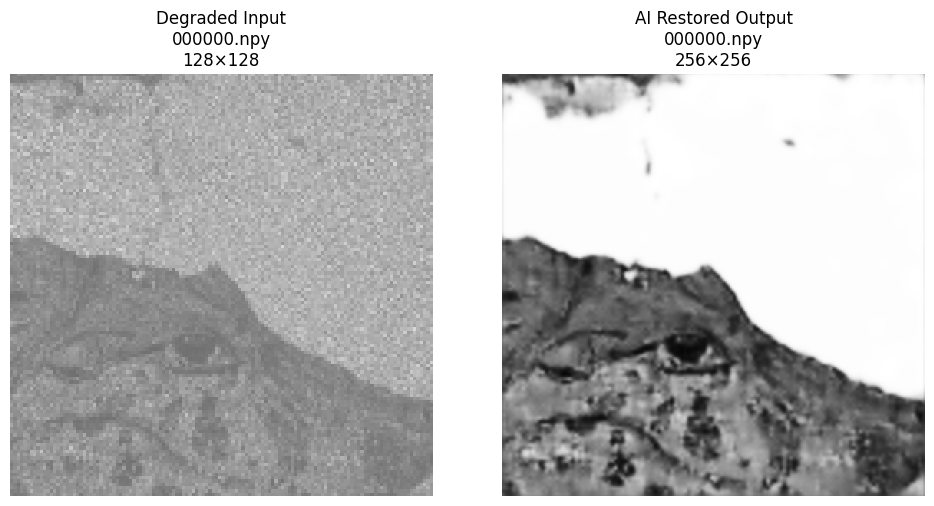

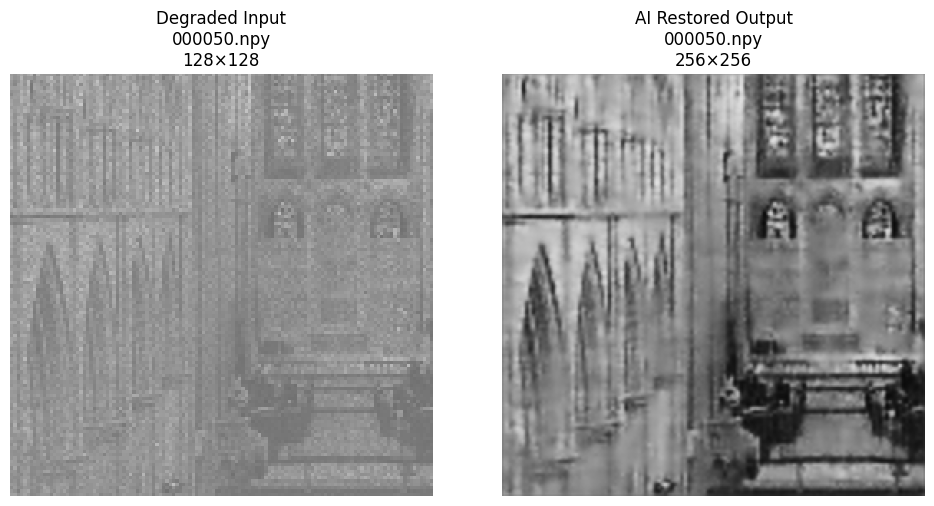

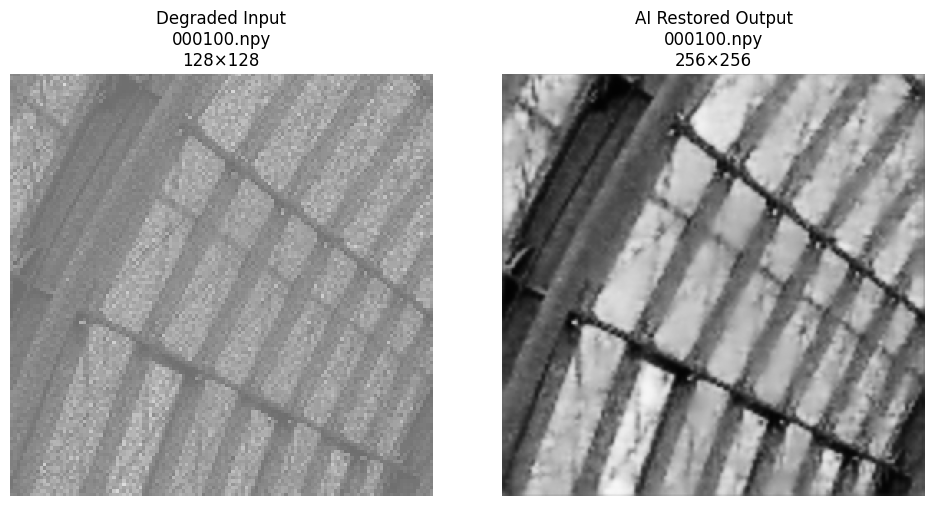

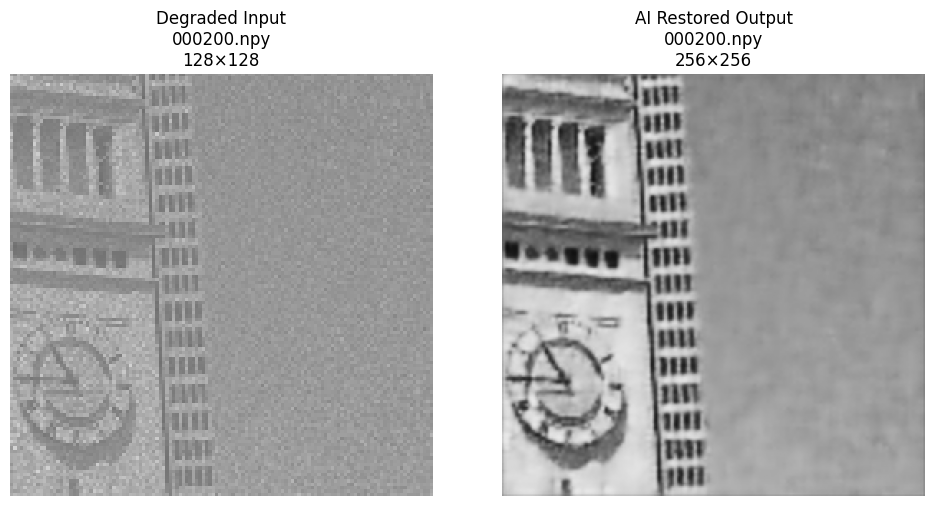

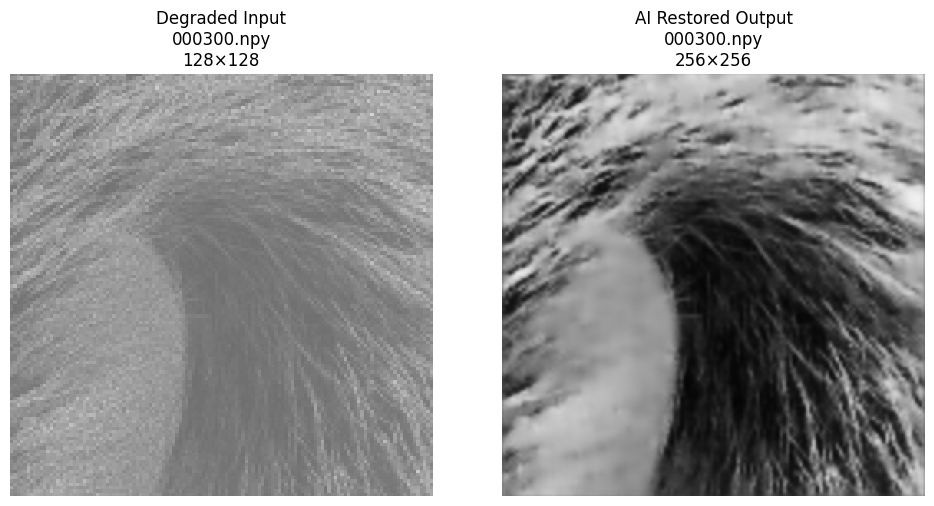

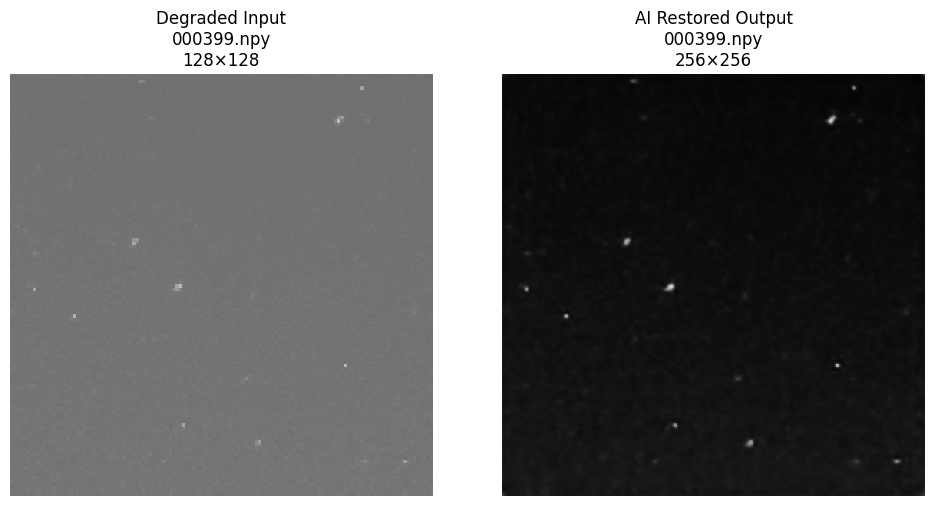

In [ ]:
# ============================================================
# KLA PS01 — TEST OUTPUT VISUALIZATION
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# SELECT TEST IMAGES
# ============================================================

# Select a few representative test samples
sample_indices = [0, 50, 100, 200, 300, 399]

selected_files = [
    test_files[i]
    for i in sample_indices
]


# ============================================================
# DISPLAY INPUT → RESTORED
# ============================================================

for filename in selected_files:

    input_path = os.path.join(
        TEST_INPUT_DIR,
        filename
    )

    output_path = os.path.join(
        TEST_OUTPUT_DIR,
        filename
    )

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    noisy = np.load(
        input_path
    ).astype(np.float32)

    restored = np.load(
        output_path
    ).astype(np.float32)

    noisy = np.squeeze(noisy)
    restored = np.squeeze(restored)

    # --------------------------------------------------------
    # Undo normalization for input visualization
    # --------------------------------------------------------

    noisy_display = (
        noisy * 0.284787
        + 0.433536
    )

    noisy_display = np.clip(
        noisy_display,
        0,
        1
    )

    restored_display = np.clip(
        restored,
        0,
        1
    )

    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 5)
    )

    axes[0].imshow(
        noisy_display,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[0].set_title(
        f"Degraded Input\n{filename}\n128×128"
    )

    axes[1].imshow(
        restored_display,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        f"AI Restored Output\n{filename}\n256×256"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

CREATING FINAL KLA PS01 RESULTS

Validation results:


,Metric,Bicubic,AI_Model,Improvement
0,PSNR (dB),22.711670,25.074609,2.362939
1,SSIM,0.528509,0.720521,0.192012
2,LPIPS,NaN,0.354090,NaN
3,MAE,0.056934,0.045348,0.011586



Saved: /content/drive/MyDrive/KLA_PS01/results/validation_results.csv

Inference results:
test_images: 400
outputs_saved: 400
average_inference_seconds: 0.011315994960027638
median_inference_seconds: 0.01058115000023463
fastest_inference_seconds: 0.00825446999988344
slowest_inference_seconds: 0.08333012200000667
total_inference_seconds: 4.526397984011055
average_inference_ms: 11.315994960027638
device: Tesla T4

Saved: /content/drive/MyDrive/KLA_PS01/results/inference_results.csv

Model information:
model: KLAResUNet
parameters: 1821101
trainable_parameters: 1821101
input_resolution: 128x128
output_resolution: 256x256
input_channels: 1
output_channels: 1
training_images: 2880
validation_images: 320
test_images: 400
batch_size: 8
epochs_completed: 30
learning_rate_initial: 0.0001
weight_decay: 0.0001
model_checkpoint_size_MB: 21.03234577178955
gpu: Tesla T4


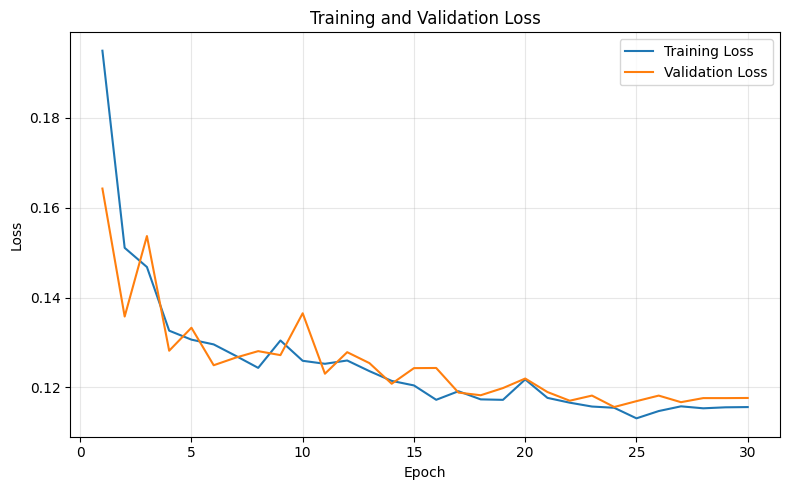

Saved: /content/drive/MyDrive/KLA_PS01/figures/training_validation_loss.png


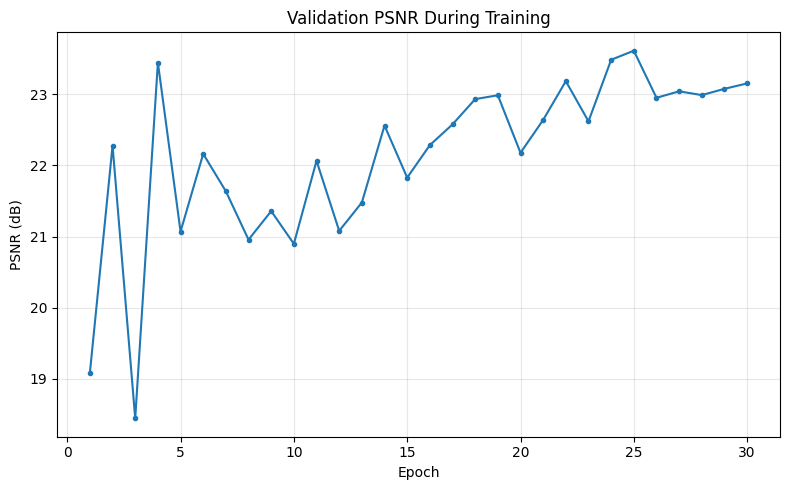

Saved: /content/drive/MyDrive/KLA_PS01/figures/validation_psnr.png


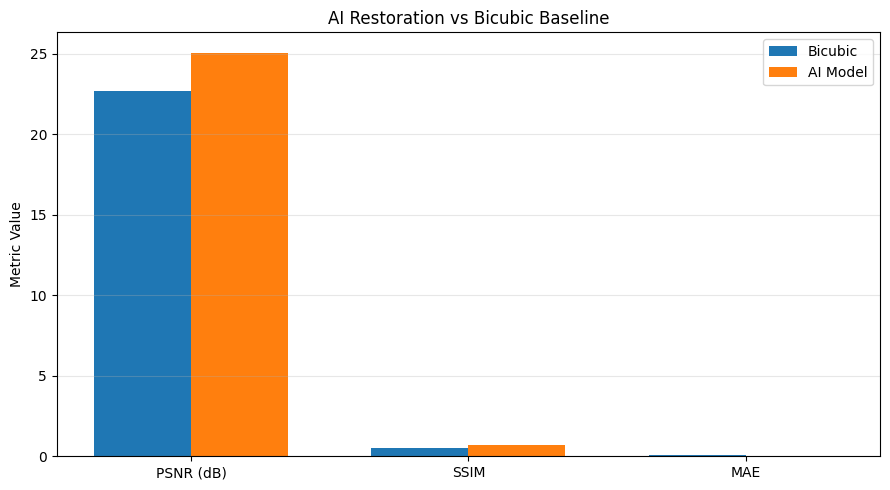

Saved: /content/drive/MyDrive/KLA_PS01/figures/ai_vs_bicubic.png

FINAL RESULTS PACKAGE CREATED

Results directory:
/content/drive/MyDrive/KLA_PS01/results

Figures directory:
/content/drive/MyDrive/KLA_PS01/figures

Best model:
/content/drive/MyDrive/KLA_PS01/checkpoints/kla_resunet_best.pt

Test outputs:
/content/drive/MyDrive/KLA_PS01/outputs/test_restored

✅ All final results saved to Google Drive.


In [ ]:
# ============================================================
# KLA PS01 — FINAL RESULTS & FIGURES
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Results directory
# ------------------------------------------------------------

RESULTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results"
)

FIGURES_DIR = os.path.join(
    PROJECT_ROOT,
    "figures"
)

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print("=" * 70)
print("CREATING FINAL KLA PS01 RESULTS")
print("=" * 70)


# ============================================================
# 1. FINAL METRICS TABLE
# ============================================================

results_table = pd.DataFrame({
    "Metric": [
        "PSNR (dB)",
        "SSIM",
        "LPIPS",
        "MAE"
    ],

    "Bicubic": [
        bicubic_psnr_mean,
        bicubic_ssim_mean,
        np.nan,
        bicubic_mae_mean
    ],

    "AI_Model": [
        mean_psnr,
        mean_ssim,
        mean_lpips,
        mean_mae
    ]
})

# Calculate improvements
results_table["Improvement"] = [
    mean_psnr - bicubic_psnr_mean,
    mean_ssim - bicubic_ssim_mean,
    np.nan,
    bicubic_mae_mean - mean_mae
]

results_csv = os.path.join(
    RESULTS_DIR,
    "validation_results.csv"
)

results_table.to_csv(
    results_csv,
    index=False
)

print("\nValidation results:")
display(results_table)

print(
    "\nSaved:",
    results_csv
)


# ============================================================
# 2. INFERENCE RESULTS
# ============================================================

inference_results = {
    "test_images": len(test_files),
    "outputs_saved": len(output_files),
    "average_inference_seconds": float(mean_time),
    "median_inference_seconds": float(median_time),
    "fastest_inference_seconds": float(min_time),
    "slowest_inference_seconds": float(max_time),
    "total_inference_seconds": float(total_time),
    "average_inference_ms": float(mean_time * 1000),
    "device": torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
}

inference_csv = os.path.join(
    RESULTS_DIR,
    "inference_results.csv"
)

pd.DataFrame(
    [inference_results]
).to_csv(
    inference_csv,
    index=False
)

print("\nInference results:")
for key, value in inference_results.items():
    print(f"{key}: {value}")

print(
    "\nSaved:",
    inference_csv
)


# ============================================================
# 3. MODEL INFORMATION
# ============================================================

model_size_mb = (
    os.path.getsize(BEST_MODEL_PATH)
    / (1024 ** 2)
)

model_info = {
    "model": "KLAResUNet",
    "parameters": int(total_params),
    "trainable_parameters": int(trainable_params),
    "input_resolution": "128x128",
    "output_resolution": "256x256",
    "input_channels": 1,
    "output_channels": 1,
    "training_images": len(train_dataset),
    "validation_images": len(val_dataset),
    "test_images": len(test_files),
    "batch_size": BATCH_SIZE,
    "epochs_completed": len(history["train_loss"]),
    "learning_rate_initial": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "model_checkpoint_size_MB": model_size_mb,
    "gpu": torch.cuda.get_device_name(0)
    if torch.cuda.is_available()
    else "CPU"
}

model_info_csv = os.path.join(
    RESULTS_DIR,
    "model_information.csv"
)

pd.DataFrame(
    [model_info]
).to_csv(
    model_info_csv,
    index=False
)

print("\nModel information:")
for key, value in model_info.items():
    print(f"{key}: {value}")


# ============================================================
# 4. TRAINING CURVES
# ============================================================

epochs = np.arange(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

loss_fig = os.path.join(
    FIGURES_DIR,
    "training_validation_loss.png"
)

plt.tight_layout()
plt.savefig(
    loss_fig,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", loss_fig)


# ============================================================
# 5. VALIDATION PSNR CURVE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["val_psnr"],
    marker="o",
    markersize=3
)

plt.xlabel("Epoch")
plt.ylabel("PSNR (dB)")
plt.title("Validation PSNR During Training")
plt.grid(alpha=0.3)

psnr_fig = os.path.join(
    FIGURES_DIR,
    "validation_psnr.png"
)

plt.tight_layout()
plt.savefig(
    psnr_fig,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", psnr_fig)


# ============================================================
# 6. AI VS BICUBIC COMPARISON
# ============================================================

comparison_metrics = [
    "PSNR (dB)",
    "SSIM",
    "MAE"
]

bicubic_values = [
    bicubic_psnr_mean,
    bicubic_ssim_mean,
    bicubic_mae_mean
]

ai_values = [
    mean_psnr,
    mean_ssim,
    mean_mae
]

x = np.arange(
    len(comparison_metrics)
)

width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    bicubic_values,
    width,
    label="Bicubic"
)

plt.bar(
    x + width / 2,
    ai_values,
    width,
    label="AI Model"
)

plt.xticks(
    x,
    comparison_metrics
)

plt.ylabel("Metric Value")
plt.title("AI Restoration vs Bicubic Baseline")
plt.legend()
plt.grid(
    axis="y",
    alpha=0.3
)

comparison_fig = os.path.join(
    FIGURES_DIR,
    "ai_vs_bicubic.png"
)

plt.tight_layout()
plt.savefig(
    comparison_fig,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", comparison_fig)


# ============================================================
# 7. SAVE COMPLETE SUMMARY JSON
# ============================================================

summary = {
    "validation": {
        "psnr_mean_db": float(mean_psnr),
        "psnr_median_db": float(median_psnr),
        "ssim_mean": float(mean_ssim),
        "ssim_median": float(median_ssim),
        "lpips_mean": float(mean_lpips),
        "lpips_median": float(median_lpips),
        "mae_mean": float(mean_mae)
    },

    "bicubic_baseline": {
        "psnr_mean_db": float(bicubic_psnr_mean),
        "ssim_mean": float(bicubic_ssim_mean),
        "mae_mean": float(bicubic_mae_mean)
    },

    "improvement": {
        "psnr_db": float(
            mean_psnr - bicubic_psnr_mean
        ),
        "ssim": float(
            mean_ssim - bicubic_ssim_mean
        ),
        "mae_reduction": float(
            bicubic_mae_mean - mean_mae
        ),
        "mae_reduction_percent": float(
            (
                (bicubic_mae_mean - mean_mae)
                / bicubic_mae_mean
            ) * 100
        )
    },

    "test_inference": inference_results,

    "model": model_info
}

summary_json = os.path.join(
    RESULTS_DIR,
    "final_results_summary.json"
)

with open(
    summary_json,
    "w"
) as f:
    json.dump(
        summary,
        f,
        indent=4
    )

print("\n" + "=" * 70)
print("FINAL RESULTS PACKAGE CREATED")
print("=" * 70)

print("\nResults directory:")
print(RESULTS_DIR)

print("\nFigures directory:")
print(FIGURES_DIR)

print("\nBest model:")
print(BEST_MODEL_PATH)

print("\nTest outputs:")
print(TEST_OUTPUT_DIR)

print("\n✅ All final results saved to Google Drive.")

In [ ]:
# ============================================================
# KLA PS01 — CAPTURE EXACT MODEL ARCHITECTURE
# ============================================================

import os
import inspect

SUBMISSION_DIR = "/content/drive/MyDrive/KLA_PS01/submission"

os.makedirs(SUBMISSION_DIR, exist_ok=True)

print("=" * 70)
print("CAPTURING EXACT TRAINED MODEL ARCHITECTURE")
print("=" * 70)

# ------------------------------------------------------------
# Check model
# ------------------------------------------------------------

print("Model class:", model.__class__.__name__)
print("\nModel architecture:")
print(model)

print("\n" + "=" * 70)
print("PARAMETER COUNT")
print("=" * 70)

print(
    "Total parameters:",
    sum(p.numel() for p in model.parameters())
)

print(
    "Trainable parameters:",
    sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )
)


# ------------------------------------------------------------
# Try to capture the exact class source code
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SAVING MODEL SOURCE CODE")
print("=" * 70)

try:

    model_source = inspect.getsource(
        model.__class__
    )

    model_source_path = os.path.join(
        SUBMISSION_DIR,
        "model_class_source.txt"
    )

    with open(
        model_source_path,
        "w"
    ) as f:
        f.write(model_source)

    print(
        "✅ Model source saved:"
    )
    print(model_source_path)

    print("\nFirst part of source:\n")
    print(model_source[:5000])

except Exception as e:

    print(
        "⚠️ Could not automatically extract "
        "class source."
    )

    print("Reason:", e)


# ------------------------------------------------------------
# Save model architecture text
# ------------------------------------------------------------

architecture_path = os.path.join(
    SUBMISSION_DIR,
    "model_architecture.txt"
)

with open(
    architecture_path,
    "w"
) as f:

    f.write(
        "KLA PS01 — KLAResUNet Architecture\n"
    )

    f.write("=" * 70 + "\n\n")

    f.write(
        str(model)
    )

    f.write(
        "\n\n"
    )

    f.write(
        f"Total parameters: "
        f"{sum(p.numel() for p in model.parameters())}\n"
    )

    f.write(
        f"Trainable parameters: "
        f"{sum(p.numel() for p in model.parameters() if p.requires_grad)}\n"
    )

print(
    "\n✅ Architecture saved:"
)

print(
    architecture_path
)


# ------------------------------------------------------------
# Create submission folder structure
# ------------------------------------------------------------

folders = [
    "weights",
    "outputs",
    "results",
    "figures",
    "references"
]

for folder in folders:

    path = os.path.join(
        SUBMISSION_DIR,
        folder
    )

    os.makedirs(
        path,
        exist_ok=True
    )

print("\n" + "=" * 70)
print("SUBMISSION FOLDER CREATED")
print("=" * 70)

print(SUBMISSION_DIR)

print("\nFolders:")

for folder in folders:
    print(
        "  ✓",
        folder
    )

print("\n✅ Next we will create the standalone inference.py.")

CAPTURING EXACT TRAINED MODEL ARCHITECTURE
Model class: KLAResUNet

Model architecture:
KLAResUNet(
  (input_conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): GELU(approximate='none')
  )
  (enc1): Sequential(
    (0): ResidualAttentionBlock(
      (residual): ResidualBlock(
        (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
        (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
        (activation): GELU(approximate='none')
      )
      (attention): ChannelAttention(
        (pool): AdaptiveAvgPool2d(output_size=1)
        (fc): Sequential(
          (0): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
          (1): GELU(approximate='none')
          (2): Conv2d(4, 32, kernel_size=(1, 1), stride=(1, 1))
          (3): Sigmoid()
        )
      )
    )
    (1

In [ ]:
# ============================================================
# KLA PS01 — CREATE STANDALONE model.py
# ============================================================

import os

MODEL_PY = r'''
import torch
import torch.nn as nn


# ============================================================
# BASIC RESIDUAL BLOCK
# ============================================================

class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.conv1 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(
            8,
            channels
        )

        self.conv2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(
            8,
            channels
        )

        self.activation = nn.GELU()


    def forward(self, x):

        residual = x

        x = self.conv1(x)
        x = self.norm1(x)
        x = self.activation(x)

        x = self.conv2(x)
        x = self.norm2(x)

        x = x + residual

        x = self.activation(x)

        return x


# ============================================================
# CHANNEL ATTENTION
# ============================================================

class ChannelAttention(nn.Module):

    def __init__(self, channels):

        super().__init__()

        reduced = max(
            channels // 8,
            4
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(

            nn.Conv2d(
                channels,
                reduced,
                kernel_size=1
            ),

            nn.GELU(),

            nn.Conv2d(
                reduced,
                channels,
                kernel_size=1
            ),

            nn.Sigmoid()
        )


    def forward(self, x):

        attention = self.pool(x)

        attention = self.fc(attention)

        return x * attention


# ============================================================
# RESIDUAL + ATTENTION BLOCK
# ============================================================

class ResidualAttentionBlock(nn.Module):

    def __init__(self, channels):

        super().__init__()

        self.residual = ResidualBlock(
            channels
        )

        self.attention = ChannelAttention(
            channels
        )


    def forward(self, x):

        x = self.residual(x)

        x = self.attention(x)

        return x


# ============================================================
# DOWN BLOCK
# ============================================================

class DownBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                stride=2,
                padding=1
            ),

            nn.GroupNorm(
                8,
                out_channels
            ),

            nn.GELU(),

            ResidualAttentionBlock(
                out_channels
            )
        )


    def forward(self, x):

        return self.block(x)


# ============================================================
# UP BLOCK
# ============================================================

class UpBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.fuse = nn.Sequential(

            nn.Conv2d(
                out_channels * 2,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.GroupNorm(
                8,
                out_channels
            ),

            nn.GELU(),

            ResidualAttentionBlock(
                out_channels
            )
        )


    def forward(
        self,
        x,
        skip
    ):

        x = self.up(x)

        x = torch.cat(
            [x, skip],
            dim=1
        )

        x = self.fuse(x)

        return x


# ============================================================
# KLAResUNet
# ============================================================

class KLAResUNet(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # Input
        # ----------------------------------------------------

        self.input_conv = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.GELU()
        )


        # ----------------------------------------------------
        # Encoder level 1
        # ----------------------------------------------------

        self.enc1 = nn.Sequential(

            ResidualAttentionBlock(32),

            ResidualAttentionBlock(32)
        )


        self.down1 = DownBlock(
            32,
            64
        )


        # ----------------------------------------------------
        # Encoder level 2
        # ----------------------------------------------------

        self.enc2 = nn.Sequential(

            ResidualAttentionBlock(64),

            ResidualAttentionBlock(64)
        )


        self.down2 = DownBlock(
            64,
            128
        )


        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        self.bottleneck = nn.Sequential(

            ResidualAttentionBlock(128),

            ResidualAttentionBlock(128),

            ResidualAttentionBlock(128)
        )


        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        self.up2 = UpBlock(
            128,
            64
        )

        self.up1 = UpBlock(
            64,
            32
        )


        # ----------------------------------------------------
        # Super-resolution reconstruction
        # ----------------------------------------------------

        self.pre_sr = nn.Sequential(

            nn.Conv2d(
                32,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.GELU()
        )


        self.pixel_shuffle = nn.PixelShuffle(
            2
        )


        self.output_conv = nn.Conv2d(
            32,
            1,
            kernel_size=3,
            padding=1
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(self, x):

        # ----------------------------------------------------
        # Encoder
        # ----------------------------------------------------

        x0 = self.input_conv(x)

        e1 = self.enc1(x0)

        d1 = self.down1(e1)

        e2 = self.enc2(d1)

        d2 = self.down2(e2)

        # ----------------------------------------------------
        # Bottleneck
        # ----------------------------------------------------

        b = self.bottleneck(d2)

        # ----------------------------------------------------
        # Decoder
        # ----------------------------------------------------

        u2 = self.up2(
            b,
            e2
        )

        u1 = self.up1(
            u2,
            e1
        )

        # ----------------------------------------------------
        # Super-resolution
        # ----------------------------------------------------

        x = self.pre_sr(u1)

        x = self.pixel_shuffle(x)

        x = self.output_conv(x)

        # ----------------------------------------------------
        # Output constrained to [0,1]
        # ----------------------------------------------------

        x = torch.sigmoid(x)

        return x
'''


# ============================================================
# SAVE FILE
# ============================================================

submission_dir = "/content/drive/MyDrive/KLA_PS01/submission"

model_py_path = os.path.join(
    submission_dir,
    "model.py"
)

with open(
    model_py_path,
    "w"
) as f:

    f.write(MODEL_PY)


print("=" * 70)
print("model.py CREATED")
print("=" * 70)

print(model_py_path)

print("\n✅ Standalone model definition saved.")

model.py CREATED
/content/drive/MyDrive/KLA_PS01/submission/model.py

✅ Standalone model definition saved.


In [ ]:
# ============================================================
# KLA PS01 — VERIFY STANDALONE MODEL WITH TRAINED CHECKPOINT
# ============================================================

import sys
import os
import torch

# ------------------------------------------------------------
# Add submission directory to Python path
# ------------------------------------------------------------

SUBMISSION_DIR = "/content/drive/MyDrive/KLA_PS01/submission"

if SUBMISSION_DIR not in sys.path:
    sys.path.insert(0, SUBMISSION_DIR)

# Import the standalone model
from model import KLAResUNet


# ============================================================
# CREATE STANDALONE MODEL
# ============================================================

standalone_model = KLAResUNet().to(device)


# ============================================================
# PARAMETER COUNT
# ============================================================

standalone_params = sum(
    p.numel()
    for p in standalone_model.parameters()
)

print("=" * 70)
print("STANDALONE MODEL VERIFICATION")
print("=" * 70)

print("Original model parameters   :", total_params)
print("Standalone model parameters :", standalone_params)

if standalone_params == total_params:
    print("✅ Parameter count matches exactly.")
else:
    print("❌ PARAMETER COUNT MISMATCH!")


# ============================================================
# LOAD TRAINED CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

state_dict = checkpoint["model_state_dict"]


# ------------------------------------------------------------
# Try loading
# ------------------------------------------------------------

try:

    standalone_model.load_state_dict(
        state_dict,
        strict=True
    )

    print(
        "✅ Trained checkpoint loaded successfully."
    )

except Exception as e:

    print(
        "❌ CHECKPOINT LOADING FAILED"
    )

    print(e)

    raise


# ============================================================
# FORWARD-PASS TEST
# ============================================================

standalone_model.eval()

# Use the same shape as the real input
test_tensor = torch.randn(
    1,
    1,
    128,
    128,
    device=device
)

with torch.no_grad():

    standalone_output = standalone_model(
        test_tensor
    )


print("\n" + "=" * 70)
print("FORWARD PASS VERIFICATION")
print("=" * 70)

print(
    "Input shape  :",
    tuple(test_tensor.shape)
)

print(
    "Output shape :",
    tuple(standalone_output.shape)
)

print(
    "Output range :",
    float(standalone_output.min()),
    "to",
    float(standalone_output.max())
)


# ============================================================
# EXPECTED OUTPUT CHECK
# ============================================================

assert standalone_params == total_params, \
    "Standalone parameter count does not match original model."

assert tuple(
    standalone_output.shape
) == (1, 1, 256, 256), \
    "Standalone model output shape is incorrect."

print("\n" + "=" * 70)
print("✅ STANDALONE MODEL VERIFICATION PASSED")
print("=" * 70)

print(
    "The GitHub model.py can load the trained checkpoint."
)

print(
    "We can now safely create inference.py."
)

STANDALONE MODEL VERIFICATION
Original model parameters   : 1821101
Standalone model parameters : 1821101
✅ Parameter count matches exactly.
✅ Trained checkpoint loaded successfully.

FORWARD PASS VERIFICATION
Input shape  : (1, 1, 128, 128)
Output shape : (1, 1, 256, 256)
Output range : 0.006067072972655296 to 0.8843508362770081

✅ STANDALONE MODEL VERIFICATION PASSED
The GitHub model.py can load the trained checkpoint.
We can now safely create inference.py.


In [ ]:
# ============================================================
# KLA PS01 — CREATE STANDALONE inference.py
# ============================================================

import os

SUBMISSION_DIR = "/content/drive/MyDrive/KLA_PS01/submission"

INFERENCE_PY = r'''
import argparse
import os
import time

import numpy as np
import torch

from model import KLAResUNet


# ============================================================
# CONFIGURATION
# ============================================================

# These are the exact normalization statistics used
# during training.
MEAN = 0.433536
STD = 0.284787


# ============================================================
# DEVICE
# ============================================================

def get_device():

    if torch.cuda.is_available():
        return torch.device("cuda")

    return torch.device("cpu")


# ============================================================
# LOAD MODEL
# ============================================================

def load_model(weights_path, device):

    model = KLAResUNet().to(device)

    checkpoint = torch.load(
        weights_path,
        map_location=device,
        weights_only=False
    )

    # The submitted checkpoint contains:
    # checkpoint["model_state_dict"]
    if isinstance(checkpoint, dict) and \
       "model_state_dict" in checkpoint:

        state_dict = checkpoint[
            "model_state_dict"
        ]

    else:

        # Also support a raw state_dict
        state_dict = checkpoint

    model.load_state_dict(
        state_dict,
        strict=True
    )

    model.eval()

    return model


# ============================================================
# LOAD INPUT IMAGE
# ============================================================

def load_input(path, device):

    image = np.load(path).astype(
        np.float32
    )

    # Remove dimensions of size 1
    image = np.squeeze(image)

    if image.ndim != 2:
        raise ValueError(
            f"Expected a 2D grayscale image, "
            f"but {path} has shape {image.shape}"
        )

    # Expected challenge input resolution
    if image.shape != (128, 128):

        raise ValueError(
            f"Expected input shape (128, 128), "
            f"but {path} has shape {image.shape}"
        )

    # Convert:
    # (128,128)
    # ->
    # (1,1,128,128)

    tensor = torch.from_numpy(
        image
    ).unsqueeze(0).unsqueeze(0)

    tensor = tensor.to(
        device
    )

    # Same normalization used during training
    tensor = (
        tensor - MEAN
    ) / STD

    return tensor


# ============================================================
# RESTORE ONE IMAGE
# ============================================================

def restore_image(
    model,
    input_path,
    output_path,
    device
):

    tensor = load_input(
        input_path,
        device
    )

    with torch.no_grad():

        restored = model(
            tensor
        )

    # Convert:
    # (1,1,256,256)
    # ->
    # (256,256)

    restored = (
        restored
        .squeeze()
        .cpu()
        .numpy()
    )

    # Model output is already constrained
    # to [0,1], but clip for safety.

    restored = np.clip(
        restored,
        0.0,
        1.0
    ).astype(
        np.float32
    )

    np.save(
        output_path,
        restored
    )


# ============================================================
# MAIN
# ============================================================

def main():

    parser = argparse.ArgumentParser(
        description=(
            "KLA PS01 AI image restoration "
            "inference"
        )
    )

    parser.add_argument(
        "--input_dir",
        required=True,
        help=(
            "Directory containing degraded "
            ".npy images"
        )
    )

    parser.add_argument(
        "--output_dir",
        required=True,
        help=(
            "Directory where restored "
            ".npy images will be saved"
        )
    )

    parser.add_argument(
        "--weights",
        default=None,
        help=(
            "Path to trained model weights. "
            "Defaults to weights/"
            "kla_resunet_best.pt relative "
            "to this script."
        )
    )

    args = parser.parse_args()

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    script_dir = os.path.dirname(
        os.path.abspath(__file__)
    )

    if args.weights is None:

        weights_path = os.path.join(
            script_dir,
            "weights",
            "kla_resunet_best.pt"
        )

    else:

        weights_path = args.weights

    # --------------------------------------------------------
    # Validate paths
    # --------------------------------------------------------

    if not os.path.isdir(
        args.input_dir
    ):

        raise FileNotFoundError(
            f"Input directory not found: "
            f"{args.input_dir}"
        )

    if not os.path.isfile(
        weights_path
    ):

        raise FileNotFoundError(
            f"Model weights not found: "
            f"{weights_path}"
        )

    os.makedirs(
        args.output_dir,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = get_device()

    print("=" * 70)
    print("KLA PS01 — INFERENCE")
    print("=" * 70)

    print(
        "Device:",
        device
    )

    if device.type == "cuda":

        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )

    print(
        "Input directory:",
        args.input_dir
    )

    print(
        "Output directory:",
        args.output_dir
    )

    print(
        "Weights:",
        weights_path
    )

    # --------------------------------------------------------
    # Load model
    # --------------------------------------------------------

    print("\nLoading model...")

    model = load_model(
        weights_path,
        device
    )

    print(
        "Model loaded successfully."
    )

    # --------------------------------------------------------
    # Find input files
    # --------------------------------------------------------

    input_files = sorted(
        [
            filename
            for filename in os.listdir(
                args.input_dir
            )
            if filename.endswith(".npy")
            and not filename.startswith("._")
        ]
    )

    if len(input_files) == 0:

        raise RuntimeError(
            "No .npy images found in "
            "the input directory."
        )

    print(
        f"Images found: {len(input_files)}"
    )

    # --------------------------------------------------------
    # Inference
    # --------------------------------------------------------

    times = []

    print("\nStarting inference...\n")

    for index, filename in enumerate(
        input_files
    ):

        input_path = os.path.join(
            args.input_dir,
            filename
        )

        output_path = os.path.join(
            args.output_dir,
            filename
        )

        start = time.perf_counter()

        restore_image(
            model,
            input_path,
            output_path,
            device
        )

        # Synchronize GPU before measuring time
        if device.type == "cuda":

            torch.cuda.synchronize()

        elapsed = (
            time.perf_counter()
            - start
        )

        times.append(elapsed)

        if (
            index == 0
            or (index + 1) % 50 == 0
            or index == len(input_files) - 1
        ):

            print(
                f"Processed "
                f"{index + 1}/"
                f"{len(input_files)} "
                f"| {filename} "
                f"| {elapsed:.4f} sec"
            )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    times = np.asarray(
        times
    )

    print("\n" + "=" * 70)
    print("INFERENCE COMPLETE")
    print("=" * 70)

    print(
        f"Images processed : "
        f"{len(input_files)}"
    )

    print(
        f"Average time     : "
        f"{times.mean():.6f} sec/image"
    )

    print(
        f"Median time      : "
        f"{np.median(times):.6f} sec/image"
    )

    print(
        f"Total time       : "
        f"{times.sum():.4f} sec"
    )

    print(
        "Output directory:",
        args.output_dir
    )

    print("\nDone.")


if __name__ == "__main__":

    main()
'''


# ============================================================
# SAVE inference.py
# ============================================================

inference_path = os.path.join(
    SUBMISSION_DIR,
    "inference.py"
)

with open(
    inference_path,
    "w"
) as f:

    f.write(INFERENCE_PY)


print("=" * 70)
print("inference.py CREATED")
print("=" * 70)

print(
    inference_path
)

print(
    "\n✅ Standalone inference script saved."
)

print(
    "\nNext we will test this script AS A STANDALONE"
    " PROGRAM on the 400 test images."
)

inference.py CREATED
/content/drive/MyDrive/KLA_PS01/submission/inference.py

✅ Standalone inference script saved.

Next we will test this script AS A STANDALONE PROGRAM on the 400 test images.


In [ ]:
# ============================================================
# KLA PS01 — FIX WEIGHTS + RUN STANDALONE INFERENCE
# ============================================================

import os
import shutil
import subprocess
import sys
import numpy as np


# ============================================================
# PATHS
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"

SUBMISSION_DIR = os.path.join(
    PROJECT_ROOT,
    "submission"
)

SOURCE_WEIGHTS = os.path.join(
    PROJECT_ROOT,
    "checkpoints",
    "kla_resunet_best.pt"
)

WEIGHTS_DIR = os.path.join(
    SUBMISSION_DIR,
    "weights"
)

DESTINATION_WEIGHTS = os.path.join(
    WEIGHTS_DIR,
    "kla_resunet_best.pt"
)

INFERENCE_SCRIPT = os.path.join(
    SUBMISSION_DIR,
    "inference.py"
)

MODEL_SCRIPT = os.path.join(
    SUBMISSION_DIR,
    "model.py"
)

TEST_INPUT_DIR = (
    "/content/KLA_PS01_dataset/"
    "test/NoisyLR"
)

STANDALONE_OUTPUT_DIR = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "standalone_test"
)


# ============================================================
# CREATE REQUIRED FOLDERS
# ============================================================

os.makedirs(
    WEIGHTS_DIR,
    exist_ok=True
)

os.makedirs(
    STANDALONE_OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# VERIFY ORIGINAL CHECKPOINT
# ============================================================

print("=" * 70)
print("STEP 1 — CHECKING ORIGINAL CHECKPOINT")
print("=" * 70)

print(
    "Original checkpoint:",
    SOURCE_WEIGHTS
)

if not os.path.isfile(SOURCE_WEIGHTS):

    raise FileNotFoundError(
        "Original trained checkpoint was not found."
    )

print(
    "✅ Original checkpoint exists."
)

print(
    "Checkpoint size:",
    round(
        os.path.getsize(SOURCE_WEIGHTS)
        / (1024 ** 2),
        2
    ),
    "MB"
)


# ============================================================
# COPY WEIGHTS INTO SUBMISSION
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — COPYING MODEL WEIGHTS")
print("=" * 70)

shutil.copy2(
    SOURCE_WEIGHTS,
    DESTINATION_WEIGHTS
)

print(
    "Destination:",
    DESTINATION_WEIGHTS
)

print(
    "✅ Model weights copied successfully."
)


# ============================================================
# VERIFY SUBMISSION FILES
# ============================================================

print("\n" + "=" * 70)
print("STEP 3 — VERIFYING SUBMISSION FILES")
print("=" * 70)

required_files = {
    "model.py": MODEL_SCRIPT,
    "inference.py": INFERENCE_SCRIPT,
    "kla_resunet_best.pt": DESTINATION_WEIGHTS
}

for name, path in required_files.items():

    exists = os.path.isfile(path)

    print(
        f"{name:<25}:",
        exists
    )

    if not exists:

        raise FileNotFoundError(
            f"Required file missing: {path}"
        )

print(
    "\n✅ All required standalone files exist."
)


# ============================================================
# CLEAN PREVIOUS STANDALONE OUTPUTS
# ============================================================

for filename in os.listdir(
    STANDALONE_OUTPUT_DIR
):

    filepath = os.path.join(
        STANDALONE_OUTPUT_DIR,
        filename
    )

    if os.path.isfile(filepath):

        os.remove(filepath)


# ============================================================
# RUN inference.py AS A SEPARATE PROGRAM
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 — RUNNING STANDALONE inference.py")
print("=" * 70)

command = [
    sys.executable,
    INFERENCE_SCRIPT,

    "--input_dir",
    TEST_INPUT_DIR,

    "--output_dir",
    STANDALONE_OUTPUT_DIR
]

print(
    "Command:"
)

print(
    " ".join(command)
)

print("\nRunning...\n")


result = subprocess.run(
    command,
    text=True,
    capture_output=True
)


# ============================================================
# SHOW OUTPUT
# ============================================================

print("=" * 70)
print("STANDALONE SCRIPT OUTPUT")
print("=" * 70)

print(result.stdout)

if result.stderr:

    print("\nSTDERR:")
    print(result.stderr)


# ============================================================
# CHECK EXIT STATUS
# ============================================================

if result.returncode != 0:

    print("\n" + "=" * 70)
    print("❌ STANDALONE INFERENCE FAILED")
    print("=" * 70)

    print(
        "Return code:",
        result.returncode
    )

    raise RuntimeError(
        "inference.py failed. "
        "See the output above."
    )


# ============================================================
# COUNT INPUTS
# ============================================================

input_files = sorted([
    f
    for f in os.listdir(TEST_INPUT_DIR)
    if f.endswith(".npy")
    and not f.startswith("._")
])

output_files = sorted([
    f
    for f in os.listdir(STANDALONE_OUTPUT_DIR)
    if f.endswith(".npy")
    and not f.startswith("._")
])


# ============================================================
# VERIFY OUTPUTS
# ============================================================

print("\n" + "=" * 70)
print("STEP 5 — VERIFYING OUTPUTS")
print("=" * 70)

print(
    "Input images :",
    len(input_files)
)

print(
    "Output images:",
    len(output_files)
)

if len(input_files) != len(output_files):

    raise RuntimeError(
        f"Output count mismatch: "
        f"{len(input_files)} inputs vs "
        f"{len(output_files)} outputs."
    )


# ============================================================
# CHECK ONE OUTPUT
# ============================================================

sample_filename = output_files[0]

sample_path = os.path.join(
    STANDALONE_OUTPUT_DIR,
    sample_filename
)

sample = np.load(
    sample_path
)

print(
    "\nSample output:",
    sample_filename
)

print(
    "Shape :",
    sample.shape
)

print(
    "Dtype :",
    sample.dtype
)

print(
    "Min   :",
    float(sample.min())
)

print(
    "Max   :",
    float(sample.max())
)


# ============================================================
# ASSERTIONS
# ============================================================

assert sample.shape == (
    256,
    256
), "Output is not 256×256."

assert sample.dtype == np.float32, \
    "Output is not float32."

assert sample.min() >= 0.0, \
    "Output contains values below 0."

assert sample.max() <= 1.0, \
    "Output contains values above 1."


# ============================================================
# FINAL SUCCESS
# ============================================================

print("\n" + "=" * 70)
print("✅ STANDALONE INFERENCE TEST PASSED")
print("=" * 70)

print(
    f"Successfully processed "
    f"{len(output_files)}/{len(input_files)} images."
)

print(
    "\nSubmission inference.py is working."
)

print(
    "Model weights are correctly packaged."
)

print(
    "Outputs are 256×256 float32 arrays."
)

STEP 1 — CHECKING ORIGINAL CHECKPOINT
Original checkpoint: /content/drive/MyDrive/KLA_PS01/checkpoints/kla_resunet_best.pt
✅ Original checkpoint exists.
Checkpoint size: 21.03 MB

STEP 2 — COPYING MODEL WEIGHTS
Destination: /content/drive/MyDrive/KLA_PS01/submission/weights/kla_resunet_best.pt
✅ Model weights copied successfully.

STEP 3 — VERIFYING SUBMISSION FILES
model.py                 : True
inference.py             : True
kla_resunet_best.pt      : True

✅ All required standalone files exist.

STEP 4 — RUNNING STANDALONE inference.py
Command:
/usr/bin/python3 /content/drive/MyDrive/KLA_PS01/submission/inference.py --input_dir /content/KLA_PS01_dataset/test/NoisyLR --output_dir /content/drive/MyDrive/KLA_PS01/outputs/standalone_test

Running...

STANDALONE SCRIPT OUTPUT
KLA PS01 — INFERENCE
Device: cuda
GPU: Tesla T4
Input directory: /content/KLA_PS01_dataset/test/NoisyLR
Output directory: /content/drive/MyDrive/KLA_PS01/outputs/standalone_test
Weights: /content/drive/MyDrive/KLA

In [ ]:
# ============================================================
# KLA PS01 — CREATE requirements.txt
# ============================================================

import os
import subprocess
import sys

SUBMISSION_DIR = (
    "/content/drive/MyDrive/KLA_PS01/submission"
)

requirements_path = os.path.join(
    SUBMISSION_DIR,
    "requirements.txt"
)

# ------------------------------------------------------------
# Get installed package versions
# ------------------------------------------------------------

packages = [
    "numpy",
    "torch",
    "torchvision"
]

lines = []

for package in packages:

    try:

        result = subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "show",
                package
            ],
            capture_output=True,
            text=True
        )

        version = None

        for line in result.stdout.splitlines():

            if line.startswith("Version:"):

                version = line.split(
                    ":", 1
                )[1].strip()

                break

        if version:

            lines.append(
                f"{package}=={version}"
            )

    except Exception as e:

        print(
            f"Could not determine version "
            f"for {package}: {e}"
        )


# ------------------------------------------------------------
# Add Python standard requirements used by script
# ------------------------------------------------------------

# os, argparse, time, shutil, sys
# are Python standard library modules
# and do NOT belong in requirements.txt.


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

with open(
    requirements_path,
    "w"
) as f:

    f.write(
        "\n".join(lines)
    )

    f.write("\n")


print("=" * 70)
print("requirements.txt CREATED")
print("=" * 70)

print(
    requirements_path
)

print("\nContents:\n")

print(
    "\n".join(lines)
)

print(
    "\n✅ requirements.txt saved."
)

requirements.txt CREATED
/content/drive/MyDrive/KLA_PS01/submission/requirements.txt

Contents:

numpy==2.0.2
torch==2.11.0+cu128
torchvision==0.26.0+cu128

✅ requirements.txt saved.


In [ ]:
# ============================================================
# KLA PS01 — CREATE README.md (SAFE VERSION)
# ============================================================

import os

SUBMISSION_DIR = "/content/drive/MyDrive/KLA_PS01/submission"
README_PATH = os.path.join(SUBMISSION_DIR, "README.md")

readme_parts = []

readme_parts.append("""
# KLA PS01 — AI-Based Restoration of Degraded Images

## 1. Project Overview

This project addresses the AI-Based Restoration of Degraded Images
problem for semiconductor inspection.

The goal is to reconstruct a clean, high-resolution image from a
degraded low-resolution noisy inspection image.

### Input

- 128 × 128 pixels
- Single-channel grayscale
- Noisy and low-resolution

### Output

- 256 × 256 pixels
- Single-channel grayscale
- Restored image

---
""")

readme_parts.append("""
## 2. Proposed Solution

We use a lightweight residual attention U-Net architecture called
**KLAResUNet**.

The model combines:

- Convolutional feature extraction
- Residual blocks
- Channel attention
- Encoder-decoder architecture
- Skip connections
- Pixel Shuffle based 2× super-resolution
- Sigmoid output reconstruction

The model contains **1,821,101 parameters**, providing a balance
between restoration quality and inference speed.

### Pipeline

    Degraded 128x128 Image
              |
              v
         Normalization
              |
              v
          KLAResUNet
              |
              v
       Encoder / Bottleneck
              |
              v
           Decoder
              |
              v
        Pixel Shuffle x2
              |
              v
       Restored 256x256 Image

---
""")

readme_parts.append("""
## 3. Dataset

The training dataset contains paired NumPy arrays.

Each sample contains:

- `GT` — clean high-resolution ground-truth image
- `NoisyLR` — degraded low-resolution image

Dataset statistics:

- Total paired samples: 3,200
- Training samples: 2,880
- Validation samples: 320
- Test images: 400

Ground truth:

    256 x 256

Degraded input:

    128 x 128

The degraded images may contain values outside the [0, 1] range.
This behaviour is expected because of the simulated degradation.

---
""")

readme_parts.append("""
## 4. Model Architecture

### KLAResUNet

Total parameters:

    1,821,101

Trainable parameters:

    1,821,101

Input:

    1 x 128 x 128

Output:

    1 x 256 x 256

Major components:

1. Input convolution
2. Residual attention encoder
3. Downsampling blocks
4. Residual attention bottleneck
5. Decoder with skip connections
6. Pixel Shuffle x2 super-resolution
7. Reconstruction convolution

---
""")

readme_parts.append("""
## 5. Training Configuration

Framework:

    PyTorch

Hardware:

    NVIDIA Tesla T4

Training configuration:

- Epochs: 30
- Batch size: 8
- Optimizer: AdamW
- Initial learning rate: 0.0001
- Weight decay: 0.0001
- Scheduler: CosineAnnealingLR
- Mixed precision: Enabled

The restoration loss combines:

- L1 reconstruction loss
- SSIM-related structural loss
- Edge loss

Loss weights:

- L1: 0.60
- SSIM: 0.25
- Edge: 0.15

Best checkpoint:

    weights/kla_resunet_best.pt

---
""")

readme_parts.append("""
## 6. Validation Results

The final model was evaluated on 320 validation images.

| Metric | AI Model |
|---|---:|
| PSNR | 25.0746 dB |
| SSIM | 0.720521 |
| LPIPS | 0.354090 |
| MAE | 0.045348 |

### Bicubic Baseline

| Metric | Bicubic | AI Model |
|---|---:|---:|
| PSNR | 22.7117 dB | 25.0746 dB |
| SSIM | 0.528509 | 0.720521 |
| MAE | 0.056934 | 0.045348 |

Improvement:

- PSNR: +2.3629 dB
- SSIM: +0.192012
- MAE reduction: approximately 20.35%

The reported PSNR, SSIM and LPIPS values are validation metrics.
The available development test set does not contain ground-truth
images, so these metrics are not claimed as official test scores.

---
""")

readme_parts.append("""
## 7. Test Inference

The available test set contains 400 degraded images.

All 400 images were successfully processed.

### Standalone inference benchmark

Hardware:

    NVIDIA Tesla T4

Average inference time:

    18.35 ms/image

Median inference time:

    15.85 ms/image

Total time for 400 images:

    7.34 seconds

The standalone benchmark is the preferred inference measurement
because it executes the actual repository inference script.

---
""")

readme_parts.append("""
## 8. Repository Structure

    KLA_PS01/
    |
    +-- README.md
    +-- model.py
    +-- inference.py
    +-- requirements.txt
    |
    +-- weights/
    |   +-- kla_resunet_best.pt
    |
    +-- outputs/
    |   +-- test_restored/
    |
    +-- results/
    |   +-- validation_results.csv
    |   +-- inference_results.csv
    |   +-- final_results_summary.json
    |
    +-- figures/
    |   +-- training_validation_loss.png
    |   +-- validation_psnr.png
    |   +-- ai_vs_bicubic.png
    |
    +-- references/

---
""")

readme_parts.append("""
## 9. Installation

Clone the repository:

    git clone <YOUR_GITHUB_REPOSITORY_URL>
    cd KLA_PS01

Create a virtual environment:

    python -m venv venv

Activate it.

Linux/macOS:

    source venv/bin/activate

Windows:

    venv\\Scripts\\activate

Install dependencies:

    pip install -r requirements.txt

---
""")

readme_parts.append("""
## 10. Running Inference

The primary evaluation script is:

    inference.py

It accepts:

    --input_dir
    --output_dir

Example:

    python inference.py --input_dir ./test/NoisyLR --output_dir ./outputs/restored

The script automatically loads:

    weights/kla_resunet_best.pt

No manual modification of the source code is required.

---
""")

readme_parts.append("""
## 11. Input and Output Format

Input files must be NumPy `.npy` files containing grayscale images
with shape:

    128 x 128

Example:

    000000.npy

The output is saved using the same filename.

Output format:

    NumPy .npy
    Shape: 256 x 256
    Dtype: float32
    Range: [0, 1]

Example:

    input/000000.npy
            |
            v
    output/000000.npy

---
""")

readme_parts.append("""
## 12. Standalone Inference Verification

The standalone inference script was tested independently on all
400 available test images.

Result:

    400 / 400 successfully processed

Verified output:

    Shape: (256, 256)
    Dtype: float32
    Range: [0, 1]

The script completed without requiring manual source-code edits.

---
""")

readme_parts.append("""
## 13. Reproducibility

The repository contains:

- `model.py` — model architecture
- `inference.py` — standalone evaluation script
- `requirements.txt` — Python dependencies
- `weights/kla_resunet_best.pt` — trained model
- `results/` — evaluation results
- `figures/` — result visualizations

A reviewer can install the dependencies and run the inference
script directly on a directory of `.npy` test images.

---
""")

readme_parts.append("""
## 14. Limitations

PSNR, SSIM and LPIPS are reported on the validation split because
the available development test images do not have corresponding
ground-truth images.

The model also has difficult restoration cases under severe
degradation. These cases are retained for honest robustness
analysis.

---
""")

readme_parts.append("""
## 15. Team

**Team Name:** <TEAM_NAME>

**Institution:** B. V. Raju Institute of Technology

**Problem Statement:** AI-Based Restoration of Degraded Images for
Semiconductor Inspection

---

## 16. License

Add the license required by the hackathon or institution before
public submission.
""")

# ------------------------------------------------------------
# Combine and write
# ------------------------------------------------------------

README = "\n".join(readme_parts)

with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(README)

# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

print("=" * 70)
print("README.md CREATED SUCCESSFULLY")
print("=" * 70)

print("Path:")
print(README_PATH)

print("\nSize:")
print(
    round(
        os.path.getsize(README_PATH) / 1024,
        2
    ),
    "KB"
)

print("\nLines:")
print(
    len(README.splitlines())
)

print("\nFirst 15 lines:")
print("\n".join(
    README.splitlines()[:15]
))

print("\n" + "=" * 70)
print("✅ README.md READY")
print("=" * 70)

README.md CREATED SUCCESSFULLY
Path:
/content/drive/MyDrive/KLA_PS01/submission/README.md

Size:
6.58 KB

Lines:
410

First 15 lines:

# KLA PS01 — AI-Based Restoration of Degraded Images

## 1. Project Overview

This project addresses the AI-Based Restoration of Degraded Images
problem for semiconductor inspection.

The goal is to reconstruct a clean, high-resolution image from a
degraded low-resolution noisy inspection image.

### Input

- 128 × 128 pixels
- Single-channel grayscale

✅ README.md READY


In [ ]:
# ============================================================
# KLA PS01 — BUILD COMPLETE SUBMISSION PACKAGE
# ============================================================

import os
import shutil

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"
SUBMISSION_DIR = os.path.join(
    PROJECT_ROOT,
    "submission"
)

print("=" * 70)
print("BUILDING KLA PS01 SUBMISSION PACKAGE")
print("=" * 70)


# ============================================================
# 1. CREATE REQUIRED DIRECTORIES
# ============================================================

directories = [
    "weights",
    "outputs",
    "outputs/test_restored",
    "results",
    "figures",
    "references"
]

for directory in directories:

    path = os.path.join(
        SUBMISSION_DIR,
        directory
    )

    os.makedirs(
        path,
        exist_ok=True
    )

print("✅ Submission directories ready.")


# ============================================================
# 2. COPY RESULTS
# ============================================================

RESULTS_SOURCE = os.path.join(
    PROJECT_ROOT,
    "results"
)

RESULTS_DEST = os.path.join(
    SUBMISSION_DIR,
    "results"
)

if os.path.exists(RESULTS_SOURCE):

    for filename in os.listdir(
        RESULTS_SOURCE
    ):

        source = os.path.join(
            RESULTS_SOURCE,
            filename
        )

        destination = os.path.join(
            RESULTS_DEST,
            filename
        )

        if os.path.isfile(source):

            shutil.copy2(
                source,
                destination
            )

    print("✅ Results copied.")


# ============================================================
# 3. COPY FIGURES
# ============================================================

FIGURES_SOURCE = os.path.join(
    PROJECT_ROOT,
    "figures"
)

FIGURES_DEST = os.path.join(
    SUBMISSION_DIR,
    "figures"
)

if os.path.exists(FIGURES_SOURCE):

    for filename in os.listdir(
        FIGURES_SOURCE
    ):

        source = os.path.join(
            FIGURES_SOURCE,
            filename
        )

        destination = os.path.join(
            FIGURES_DEST,
            filename
        )

        if os.path.isfile(source):

            shutil.copy2(
                source,
                destination
            )

    print("✅ Figures copied.")


# ============================================================
# 4. COPY TEST OUTPUTS
# ============================================================

TEST_OUTPUT_SOURCE = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "test_restored"
)

TEST_OUTPUT_DEST = os.path.join(
    SUBMISSION_DIR,
    "outputs",
    "test_restored"
)

if os.path.exists(
    TEST_OUTPUT_SOURCE
):

    output_count = 0

    for filename in os.listdir(
        TEST_OUTPUT_SOURCE
    ):

        source = os.path.join(
            TEST_OUTPUT_SOURCE,
            filename
        )

        destination = os.path.join(
            TEST_OUTPUT_DEST,
            filename
        )

        if (
            os.path.isfile(source)
            and filename.endswith(".npy")
        ):

            shutil.copy2(
                source,
                destination
            )

            output_count += 1

    print(
        f"✅ Test outputs copied: "
        f"{output_count}"
    )

else:

    print(
        "⚠️ Original test output directory "
        "not found."
    )


# ============================================================
# 5. COPY STANDALONE TEST OUTPUTS
# ============================================================

STANDALONE_SOURCE = os.path.join(
    PROJECT_ROOT,
    "outputs",
    "standalone_test"
)

STANDALONE_DEST = os.path.join(
    SUBMISSION_DIR,
    "outputs",
    "standalone_test"
)

os.makedirs(
    STANDALONE_DEST,
    exist_ok=True
)

if os.path.exists(
    STANDALONE_SOURCE
):

    standalone_count = 0

    for filename in os.listdir(
        STANDALONE_SOURCE
    ):

        source = os.path.join(
            STANDALONE_SOURCE,
            filename
        )

        destination = os.path.join(
            STANDALONE_DEST,
            filename
        )

        if (
            os.path.isfile(source)
            and filename.endswith(".npy")
        ):

            shutil.copy2(
                source,
                destination
            )

            standalone_count += 1

    print(
        f"✅ Standalone outputs copied: "
        f"{standalone_count}"
    )


# ============================================================
# 6. VERIFY MODEL WEIGHTS
# ============================================================

weights_path = os.path.join(
    SUBMISSION_DIR,
    "weights",
    "kla_resunet_best.pt"
)

if os.path.isfile(
    weights_path
):

    size_mb = (
        os.path.getsize(weights_path)
        / (1024 ** 2)
    )

    print(
        f"✅ Model weights: "
        f"{size_mb:.2f} MB"
    )

else:

    # Copy if missing
    source_weights = os.path.join(
        PROJECT_ROOT,
        "checkpoints",
        "kla_resunet_best.pt"
    )

    if os.path.isfile(
        source_weights
    ):

        shutil.copy2(
            source_weights,
            weights_path
        )

        print(
            "✅ Model weights copied."
        )

    else:

        print(
            "❌ Model weights not found."
        )


# ============================================================
# 7. FINAL FILE INVENTORY
# ============================================================

print("\n" + "=" * 70)
print("SUBMISSION PACKAGE INVENTORY")
print("=" * 70)


def show_tree(
    root,
    prefix=""
):

    items = sorted(
        os.listdir(root)
    )

    for index, item in enumerate(items):

        path = os.path.join(
            root,
            item
        )

        last = (
            index == len(items) - 1
        )

        connector = "└── " if last else "├── "

        print(
            prefix +
            connector +
            item
        )

        if os.path.isdir(path):

            extension = (
                "    "
                if last
                else "│   "
            )

            show_tree(
                path,
                prefix + extension
            )


print("submission/")
show_tree(
    SUBMISSION_DIR,
    "    "
)


# ============================================================
# 8. CHECK MANDATORY FILES
# ============================================================

mandatory_files = [
    "README.md",
    "model.py",
    "inference.py",
    "requirements.txt",
    "weights/kla_resunet_best.pt"
]

print("\n" + "=" * 70)
print("MANDATORY FILE CHECK")
print("=" * 70)

all_present = True

for relative_path in mandatory_files:

    full_path = os.path.join(
        SUBMISSION_DIR,
        relative_path
    )

    exists = os.path.isfile(
        full_path
    )

    print(
        f"{relative_path:<40}",
        "✅" if exists else "❌"
    )

    if not exists:
        all_present = False


if all_present:

    print(
        "\n🎉 ALL MANDATORY CORE FILES ARE PRESENT."
    )

else:

    print(
        "\n⚠️ Some mandatory files are missing."
    )

BUILDING KLA PS01 SUBMISSION PACKAGE
✅ Submission directories ready.
✅ Results copied.
✅ Figures copied.
✅ Test outputs copied: 400
✅ Standalone outputs copied: 400
✅ Model weights: 21.03 MB

SUBMISSION PACKAGE INVENTORY
submission/
    ├── README.md
    ├── __pycache__
    │   └── model.cpython-312.pyc
    ├── figures
    │   ├── ai_vs_bicubic.png
    │   ├── training_validation_loss.png
    │   └── validation_psnr.png
    ├── inference.py
    ├── model.py
    ├── model_architecture.txt
    ├── outputs
    │   ├── standalone_test
    │   │   ├── 000000.npy
    │   │   ├── 000001.npy
    │   │   ├── 000002.npy
    │   │   ├── 000003.npy
    │   │   ├── 000004.npy
    │   │   ├── 000005.npy
    │   │   ├── 000006.npy
    │   │   ├── 000007.npy
    │   │   ├── 000008.npy
    │   │   ├── 000009.npy
    │   │   ├── 000010.npy
    │   │   ├── 000011.npy
    │   │   ├── 000012.npy
    │   │   ├── 000013.npy
    │   │   ├── 000014.npy
    │   │   ├── 000015.npy
    │   │   ├── 000016.npy
    

In [ ]:
# ============================================================
# KLA PS01 — CREATE STANDALONE TRAINING SCRIPT
# ============================================================

import os
import textwrap

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"
SUBMISSION_DIR = os.path.join(PROJECT_ROOT, "submission")

os.makedirs(SUBMISSION_DIR, exist_ok=True)

TRAIN_SCRIPT = r'''
"""
KLA PS01 — Standalone Training Script
AI-Based Restoration of Degraded Images for Semiconductor Inspection

Input:
    128x128 grayscale noisy low-resolution .npy images

Target:
    256x256 grayscale clean ground-truth .npy images

Model:
    KLAResUNet

Loss:
    Weighted combination of:
        - L1 reconstruction loss
        - SSIM loss
        - Edge loss

This script reproduces the training procedure used for the
submitted restoration model.
"""

import os
import argparse
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, random_split

from model import KLAResUNet


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# DATASET
# ============================================================

class KLADataset(Dataset):

    def __init__(self, input_dir, target_dir):

        self.input_dir = input_dir
        self.target_dir = target_dir

        input_files = {
            f for f in os.listdir(input_dir)
            if f.endswith(".npy")
            and not f.startswith("._")
        }

        target_files = {
            f for f in os.listdir(target_dir)
            if f.endswith(".npy")
            and not f.startswith("._")
        }

        self.files = sorted(
            input_files.intersection(target_files)
        )

        if len(self.files) == 0:
            raise RuntimeError(
                "No matching .npy input/target pairs found."
            )

        print("Paired samples:", len(self.files))


    def __len__(self):
        return len(self.files)


    def __getitem__(self, index):

        filename = self.files[index]

        x = np.load(
            os.path.join(
                self.input_dir,
                filename
            )
        ).astype(np.float32)

        y = np.load(
            os.path.join(
                self.target_dir,
                filename
            )
        ).astype(np.float32)

        # Input is allowed to contain values outside [0, 1]
        # because of the degradation/noise process.

        x = torch.from_numpy(x).unsqueeze(0)
        y = torch.from_numpy(y).unsqueeze(0)

        return x, y


# ============================================================
# SSIM
# ============================================================

def gaussian_window(
    window_size=11,
    sigma=1.5,
    device="cpu"
):

    coords = torch.arange(
        window_size,
        dtype=torch.float32,
        device=device
    ) - window_size // 2

    g = torch.exp(
        -(coords ** 2) /
        (2 * sigma ** 2)
    )

    g = g / g.sum()

    window = g[:, None] * g[None, :]

    return window.unsqueeze(0).unsqueeze(0)


def ssim(
    img1,
    img2,
    window_size=11,
    sigma=1.5
):

    window = gaussian_window(
        window_size,
        sigma,
        img1.device
    )

    mu1 = F.conv2d(
        img1,
        window,
        padding=window_size // 2
    )

    mu2 = F.conv2d(
        img2,
        window,
        padding=window_size // 2
    )

    mu1_sq = mu1 * mu1
    mu2_sq = mu2 * mu2
    mu12 = mu1 * mu2

    sigma1_sq = (
        F.conv2d(
            img1 * img1,
            window,
            padding=window_size // 2
        )
        - mu1_sq
    )

    sigma2_sq = (
        F.conv2d(
            img2 * img2,
            window,
            padding=window_size // 2
        )
        - mu2_sq
    )

    sigma12 = (
        F.conv2d(
            img1 * img2,
            window,
            padding=window_size // 2
        )
        - mu12
    )

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    result = (
        (2 * mu12 + C1)
        * (2 * sigma12 + C2)
    ) / (
        (mu1_sq + mu2_sq + C1)
        * (sigma1_sq + sigma2_sq + C2)
    )

    return result.mean()


# ============================================================
# EDGE LOSS
# ============================================================

def edge_loss(pred, target):

    sobel_x = torch.tensor(
        [
            [-1, 0, 1],
            [-2, 0, 2],
            [-1, 0, 1]
        ],
        dtype=torch.float32,
        device=pred.device
    ).view(1, 1, 3, 3)

    sobel_y = torch.tensor(
        [
            [-1, -2, -1],
            [0, 0, 0],
            [1, 2, 1]
        ],
        dtype=torch.float32,
        device=pred.device
    ).view(1, 1, 3, 3)

    pred_x = F.conv2d(
        pred,
        sobel_x,
        padding=1
    )

    pred_y = F.conv2d(
        pred,
        sobel_y,
        padding=1
    )

    target_x = F.conv2d(
        target,
        sobel_x,
        padding=1
    )

    target_y = F.conv2d(
        target,
        sobel_y,
        padding=1
    )

    pred_edges = torch.sqrt(
        pred_x ** 2 +
        pred_y ** 2 +
        1e-8
    )

    target_edges = torch.sqrt(
        target_x ** 2 +
        target_y ** 2 +
        1e-8
    )

    return F.l1_loss(
        pred_edges,
        target_edges
    )


# ============================================================
# RESTORATION LOSS
# ============================================================

def restoration_loss(
    pred,
    target
):

    l1 = F.l1_loss(
        pred,
        target
    )

    ssim_loss = 1.0 - ssim(
        pred,
        target
    )

    edge = edge_loss(
        pred,
        target
    )

    total = (
        0.60 * l1
        + 0.25 * ssim_loss
        + 0.15 * edge
    )

    return total


# ============================================================
# PSNR
# ============================================================

def calculate_psnr(
    pred,
    target
):

    mse = F.mse_loss(
        pred,
        target
    ).item()

    if mse <= 1e-12:
        return 100.0

    return 10.0 * np.log10(
        1.0 / mse
    )


# ============================================================
# TRAINING
# ============================================================

def train(args):

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("=" * 70)
    print("KLA PS01 — TRAINING")
    print("=" * 70)

    print("Device:", device)

    if torch.cuda.is_available():
        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    dataset = KLADataset(
        args.input_dir,
        args.target_dir
    )

    validation_size = int(
        0.10 * len(dataset)
    )

    training_size = (
        len(dataset)
        - validation_size
    )

    train_dataset, val_dataset = random_split(
        dataset,
        [training_size, validation_size],
        generator=torch.Generator().manual_seed(SEED)
    )

    print(
        "Training samples:",
        len(train_dataset)
    )

    print(
        "Validation samples:",
        len(val_dataset)
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=args.batch_size,
        shuffle=True,
        num_workers=args.num_workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=args.batch_size,
        shuffle=False,
        num_workers=args.num_workers,
        pin_memory=torch.cuda.is_available()
    )


    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = KLAResUNet(
        in_channels=1,
        out_channels=1
    ).to(device)

    print(
        "Parameters:",
        sum(
            p.numel()
            for p in model.parameters()
        )
    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=args.learning_rate,
        weight_decay=args.weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=args.epochs,
        eta_min=1e-6
    )


    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=torch.cuda.is_available()
    )


    # --------------------------------------------------------
    # Checkpoint directory
    # --------------------------------------------------------

    os.makedirs(
        os.path.dirname(args.checkpoint),
        exist_ok=True
    )

    best_loss = float("inf")


    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(args.epochs):

        model.train()

        train_loss = 0.0


        for x, y in train_loader:

            x = x.to(
                device,
                non_blocking=True
            )

            y = y.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            with torch.amp.autocast(
                "cuda",
                enabled=torch.cuda.is_available()
            ):

                pred = model(x)

                loss = restoration_loss(
                    pred,
                    y
                )


            scaler.scale(
                loss
            ).backward()

            scaler.unscale_(
                optimizer
            )

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            scaler.step(
                optimizer
            )

            scaler.update()

            train_loss += (
                loss.item()
                * x.size(0)
            )


        train_loss /= len(
            train_loader.dataset
        )


        # ----------------------------------------------------
        # Validation
        # ----------------------------------------------------

        model.eval()

        val_loss = 0.0
        val_psnr = 0.0

        with torch.no_grad():

            for x, y in val_loader:

                x = x.to(
                    device,
                    non_blocking=True
                )

                y = y.to(
                    device,
                    non_blocking=True
                )

                pred = model(x)

                loss = restoration_loss(
                    pred,
                    y
                )

                val_loss += (
                    loss.item()
                    * x.size(0)
                )

                val_psnr += (
                    calculate_psnr(
                        pred,
                        y
                    )
                    * x.size(0)
                )


        val_loss /= len(
            val_loader.dataset
        )

        val_psnr /= len(
            val_loader.dataset
        )


        scheduler.step()


        # ----------------------------------------------------
        # Save best model
        # ----------------------------------------------------

        if val_loss < best_loss:

            best_loss = val_loss

            torch.save(
                {
                    "model_state_dict":
                        model.state_dict(),

                    "epoch":
                        epoch + 1,

                    "val_loss":
                        val_loss,

                    "val_psnr":
                        val_psnr
                },
                args.checkpoint
            )

            marker = " ⭐ BEST"

        else:

            marker = ""


        print(
            f"Epoch [{epoch + 1:02d}/{args.epochs}] "
            f"| Train Loss: {train_loss:.5f} "
            f"| Val Loss: {val_loss:.5f} "
            f"| PSNR: {val_psnr:.2f} dB "
            f"| LR: {scheduler.get_last_lr()[0]:.2e}"
            f"{marker}"
        )


    print("=" * 70)
    print("TRAINING COMPLETE")
    print("Best validation loss:", best_loss)
    print("Best checkpoint:", args.checkpoint)
    print("=" * 70)


# ============================================================
# COMMAND LINE
# ============================================================

if __name__ == "__main__":

    parser = argparse.ArgumentParser(
        description="Train KLA PS01 restoration model"
    )

    parser.add_argument(
        "--input_dir",
        required=True,
        help="Directory containing degraded NoisyLR .npy files"
    )

    parser.add_argument(
        "--target_dir",
        required=True,
        help="Directory containing clean GT .npy files"
    )

    parser.add_argument(
        "--checkpoint",
        default="kla_resunet_best.pt",
        help="Output checkpoint path"
    )

    parser.add_argument(
        "--epochs",
        type=int,
        default=30
    )

    parser.add_argument(
        "--batch_size",
        type=int,
        default=8
    )

    parser.add_argument(
        "--learning_rate",
        type=float,
        default=1e-4
    )

    parser.add_argument(
        "--weight_decay",
        type=float,
        default=1e-4
    )

    parser.add_argument(
        "--num_workers",
        type=int,
        default=2
    )

    args = parser.parse_args()

    train(args)
'''

train_path = os.path.join(
    SUBMISSION_DIR,
    "train.py"
)

with open(
    train_path,
    "w",
    encoding="utf-8"
) as f:
    f.write(
        textwrap.dedent(TRAIN_SCRIPT).strip()
        + "\n"
    )


print("=" * 70)
print("TRAINING SCRIPT CREATED")
print("=" * 70)

print("Path:")
print(train_path)

print(
    "Size:",
    os.path.getsize(train_path) / 1024,
    "KB"
)

print("\nFirst 20 lines:\n")

with open(
    train_path,
    "r",
    encoding="utf-8"
) as f:

    for i in range(20):

        line = f.readline()

        if not line:
            break

        print(
            f"{i + 1:02d}: {line.rstrip()}"
        )

print("\n✅ train.py created successfully.")

TRAINING SCRIPT CREATED
Path:
/content/drive/MyDrive/KLA_PS01/submission/train.py
Size: 13.2705078125 KB

First 20 lines:

01: """
02: KLA PS01 — Standalone Training Script
03: AI-Based Restoration of Degraded Images for Semiconductor Inspection
04: 
05: Input:
06:     128x128 grayscale noisy low-resolution .npy images
07: 
08: Target:
09:     256x256 grayscale clean ground-truth .npy images
10: 
11: Model:
12:     KLAResUNet
13: 
14: Loss:
15:     Weighted combination of:
16:         - L1 reconstruction loss
17:         - SSIM loss
18:         - Edge loss
19: 
20: This script reproduces the training procedure used for the

✅ train.py created successfully.


In [ ]:
# ============================================================
# KLA PS01 — VERIFY train.py WITHOUT TRAINING
# ============================================================

import os
import py_compile

SUBMISSION_DIR = (
    "/content/drive/MyDrive/KLA_PS01/submission"
)

TRAIN_PATH = os.path.join(
    SUBMISSION_DIR,
    "train.py"
)

MODEL_PATH = os.path.join(
    SUBMISSION_DIR,
    "model.py"
)

print("=" * 70)
print("KLA PS01 — TRAINING SCRIPT CHECK")
print("=" * 70)

print("train.py exists :", os.path.isfile(TRAIN_PATH))
print("model.py exists :", os.path.isfile(MODEL_PATH))


# ------------------------------------------------------------
# 1. Python syntax check
# ------------------------------------------------------------

try:

    py_compile.compile(
        TRAIN_PATH,
        doraise=True
    )

    print(
        "\n✅ train.py syntax check PASSED."
    )

except Exception as e:

    print(
        "\n❌ train.py syntax check FAILED."
    )

    print(e)

    raise


# ------------------------------------------------------------
# 2. Verify important sections
# ------------------------------------------------------------

with open(
    TRAIN_PATH,
    "r",
    encoding="utf-8"
) as f:

    source = f.read()


required_sections = [
    "class KLADataset",
    "class KLAResUNet",
    "def restoration_loss",
    "def edge_loss",
    "def calculate_psnr",
    "torch.optim.AdamW",
    "CosineAnnealingLR",
    "torch.save",
    "argparse",
    "--input_dir",
    "--target_dir"
]

print("\n" + "=" * 70)
print("REQUIRED CONTENT CHECK")
print("=" * 70)

for item in required_sections:

    found = item in source

    print(
        f"{item:<35}",
        "✅" if found else "❌"
    )


# ------------------------------------------------------------
# 3. IMPORTANT: check model constructor
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL CONSTRUCTOR CHECK")
print("=" * 70)

model_source = ""

with open(
    MODEL_PATH,
    "r",
    encoding="utf-8"
) as f:

    model_source = f.read()


# Our standalone KLAResUNet was created with:
#
#     KLAResUNet()
#
# rather than:
#
#     KLAResUNet(in_channels=1, out_channels=1)
#
# Check the training script for compatibility.

if (
    "KLAResUNet(\n"
    "        in_channels=1" in source
):

    print(
        "⚠️ train.py currently calls KLAResUNet "
        "with in_channels/out_channels."
    )

    print(
        "The standalone model was defined without "
        "these constructor arguments."
    )

    print(
        "\nWe will fix this before GitHub."
    )

else:

    print(
        "✅ Model constructor appears compatible."
    )


# ------------------------------------------------------------
# 4. Make sure we did NOT start training
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING SAFETY CHECK")
print("=" * 70)

print(
    "This cell only compiles and inspects train.py."
)

print(
    "No dataset loading was performed."
)

print(
    "No model training was performed."
)

print(
    "No checkpoint was overwritten."
)

print("\n✅ SAFE CHECK COMPLETE.")

KLA PS01 — TRAINING SCRIPT CHECK
train.py exists : True
model.py exists : True

✅ train.py syntax check PASSED.

REQUIRED CONTENT CHECK
class KLADataset                    ✅
class KLAResUNet                    ❌
def restoration_loss                ✅
def edge_loss                       ✅
def calculate_psnr                  ✅
torch.optim.AdamW                   ✅
CosineAnnealingLR                   ✅
torch.save                          ✅
argparse                            ✅
--input_dir                         ✅
--target_dir                        ✅

MODEL CONSTRUCTOR CHECK
⚠️ train.py currently calls KLAResUNet with in_channels/out_channels.
The standalone model was defined without these constructor arguments.

We will fix this before GitHub.

TRAINING SAFETY CHECK
This cell only compiles and inspects train.py.
No dataset loading was performed.
No model training was performed.
No checkpoint was overwritten.

✅ SAFE CHECK COMPLETE.


In [ ]:
# ============================================================
# KLA PS01 — FIX train.py MODEL CONSTRUCTOR
# ============================================================

import os

TRAIN_PATH = (
    "/content/drive/MyDrive/KLA_PS01/"
    "submission/train.py"
)

# ------------------------------------------------------------
# Read train.py
# ------------------------------------------------------------

with open(
    TRAIN_PATH,
    "r",
    encoding="utf-8"
) as f:

    source = f.read()


# ------------------------------------------------------------
# Replace incompatible constructor
# ------------------------------------------------------------

old_code = """model = KLAResUNet(
        in_channels=1,
        out_channels=1
    ).to(device)"""

new_code = """model = KLAResUNet().to(device)"""


if old_code not in source:

    print(
        "⚠️ Expected constructor was not found."
    )

    print(
        "Checking whether it is already fixed..."
    )

    if "model = KLAResUNet().to(device)" in source:

        print(
            "✅ train.py is already using "
            "the correct constructor."
        )

    else:

        raise RuntimeError(
            "Could not locate the KLAResUNet "
            "constructor in train.py."
        )

else:

    source = source.replace(
        old_code,
        new_code
    )

    with open(
        TRAIN_PATH,
        "w",
        encoding="utf-8"
    ) as f:

        f.write(source)

    print(
        "✅ train.py constructor fixed."
    )


# ============================================================
# VERIFY
# ============================================================

with open(
    TRAIN_PATH,
    "r",
    encoding="utf-8"
) as f:

    updated_source = f.read()


print("\n" + "=" * 70)
print("UPDATED MODEL CONSTRUCTOR")
print("=" * 70)

start = updated_source.find(
    "model = KLAResUNet"
)

print(
    updated_source[
        start:start + 100
    ]
)


# ============================================================
# SYNTAX CHECK
# ============================================================

import py_compile

py_compile.compile(
    TRAIN_PATH,
    doraise=True
)

print("\n" + "=" * 70)
print("✅ train.py VERIFICATION PASSED")
print("=" * 70)

print(
    "Constructor matches standalone model.py."
)

print(
    "Syntax check passed."
)

print(
    "No training was performed."
)

print(
    "Existing checkpoint was not modified."
)

✅ train.py constructor fixed.

UPDATED MODEL CONSTRUCTOR
model = KLAResUNet().to(device)

    print(
        "Parameters:",
        sum(
            p.numel(

✅ train.py VERIFICATION PASSED
Constructor matches standalone model.py.
Syntax check passed.
No training was performed.
Existing checkpoint was not modified.


In [ ]:
# ============================================================
# KLA PS01 — FINAL SUBMISSION PACKAGE CHECK
# ============================================================

import os
import shutil

PROJECT_ROOT = "/content/drive/MyDrive/KLA_PS01"
SUBMISSION_DIR = os.path.join(
    PROJECT_ROOT,
    "submission"
)

print("=" * 70)
print("KLA PS01 — FINAL PACKAGE CHECK")
print("=" * 70)


# ============================================================
# 1. REMOVE PYTHON CACHE
# ============================================================

cache_path = os.path.join(
    SUBMISSION_DIR,
    "__pycache__"
)

if os.path.exists(cache_path):

    shutil.rmtree(cache_path)

    print(
        "✅ Removed __pycache__/"
    )

else:

    print(
        "✅ No __pycache__/ found."
    )


# ============================================================
# 2. REMOVE UNNECESSARY TEMPORARY FILES
# ============================================================

temporary_names = [
    ".DS_Store",
    ".ipynb_checkpoints"
]

for root, dirs, files in os.walk(
    SUBMISSION_DIR
):

    # Remove notebook checkpoints
    for directory in list(dirs):

        if directory in temporary_names:

            path = os.path.join(
                root,
                directory
            )

            shutil.rmtree(path)

            print(
                "✅ Removed:",
                path
            )

    # Remove .DS_Store
    for filename in files:

        if filename == ".DS_Store":

            path = os.path.join(
                root,
                filename
            )

            os.remove(path)

            print(
                "✅ Removed:",
                path
            )


# ============================================================
# 3. REQUIRED FILES
# ============================================================

required_files = [
    "README.md",
    "model.py",
    "inference.py",
    "train.py",
    "requirements.txt",
    "weights/kla_resunet_best.pt"
]

print("\n" + "=" * 70)
print("REQUIRED FILES")
print("=" * 70)

all_required = True

for relative_path in required_files:

    full_path = os.path.join(
        SUBMISSION_DIR,
        relative_path
    )

    exists = os.path.isfile(
        full_path
    )

    print(
        f"{relative_path:<40}",
        "✅" if exists else "❌"
    )

    if not exists:
        all_required = False


# ============================================================
# 4. RESULTS
# ============================================================

print("\n" + "=" * 70)
print("RESULT FILES")
print("=" * 70)

results_dir = os.path.join(
    SUBMISSION_DIR,
    "results"
)

if os.path.isdir(results_dir):

    result_files = sorted(
        os.listdir(results_dir)
    )

    for filename in result_files:

        print(
            "✓",
            filename
        )

else:

    print(
        "⚠️ results/ directory missing."
    )


# ============================================================
# 5. FIGURES
# ============================================================

print("\n" + "=" * 70)
print("FIGURE FILES")
print("=" * 70)

figures_dir = os.path.join(
    SUBMISSION_DIR,
    "figures"
)

if os.path.isdir(figures_dir):

    figure_files = sorted(
        os.listdir(figures_dir)
    )

    for filename in figure_files:

        print(
            "✓",
            filename
        )

else:

    print(
        "⚠️ figures/ directory missing."
    )


# ============================================================
# 6. TEST OUTPUT COUNT
# ============================================================

print("\n" + "=" * 70)
print("TEST OUTPUT CHECK")
print("=" * 70)

output_dir = os.path.join(
    SUBMISSION_DIR,
    "outputs",
    "test_restored"
)

if os.path.isdir(output_dir):

    outputs = [
        f
        for f in os.listdir(output_dir)
        if f.endswith(".npy")
        and not f.startswith("._")
    ]

    print(
        "Restored test outputs:",
        len(outputs)
    )

    if len(outputs) == 400:

        print(
            "✅ All 400 test outputs present."
        )

    else:

        print(
            "⚠️ Expected 400 outputs."
        )

else:

    print(
        "⚠️ test_restored/ missing."
    )


# ============================================================
# 7. MODEL SIZE
# ============================================================

print("\n" + "=" * 70)
print("MODEL CHECK")
print("=" * 70)

weights_path = os.path.join(
    SUBMISSION_DIR,
    "weights",
    "kla_resunet_best.pt"
)

if os.path.isfile(weights_path):

    size_mb = (
        os.path.getsize(weights_path)
        / (1024 ** 2)
    )

    print(
        f"Model size: {size_mb:.2f} MB"
    )

else:

    print(
        "❌ Model weights missing."
    )


# ============================================================
# 8. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)

if all_required:

    print(
        "✅ CORE SUBMISSION PACKAGE IS READY"
    )

else:

    print(
        "❌ SOME REQUIRED FILES ARE MISSING"
    )

print("=" * 70)

print(
    "\nNo training was performed."
)

print(
    "No model checkpoint was modified."
)

print(
    "The next stage is adding the required references "
    "and then preparing GitHub."
)

KLA PS01 — FINAL PACKAGE CHECK
✅ Removed __pycache__/

REQUIRED FILES
README.md                                ✅
model.py                                 ✅
inference.py                             ✅
train.py                                 ✅
requirements.txt                         ✅
weights/kla_resunet_best.pt              ✅

RESULT FILES
✓ final_results_summary.json
✓ inference_results.csv
✓ model_information.csv
✓ validation_results.csv

FIGURE FILES
✓ ai_vs_bicubic.png
✓ training_validation_loss.png
✓ validation_psnr.png

TEST OUTPUT CHECK
Restored test outputs: 400
✅ All 400 test outputs present.

MODEL CHECK
Model size: 21.03 MB

✅ CORE SUBMISSION PACKAGE IS READY

No training was performed.
No model checkpoint was modified.
The next stage is adding the required references and then preparing GitHub.


In [ ]:
# ============================================================
# KLA PS01 — CREATE REFERENCES.md
# ============================================================

import os

SUBMISSION_DIR = (
    "/content/drive/MyDrive/KLA_PS01/submission"
)

REFERENCES_DIR = os.path.join(
    SUBMISSION_DIR,
    "references"
)

os.makedirs(
    REFERENCES_DIR,
    exist_ok=True
)

REFERENCES_PATH = os.path.join(
    REFERENCES_DIR,
    "REFERENCES.md"
)


REFERENCES = r"""# KLA PS01 — Supporting References

## Purpose

These references support the technical motivation and design choices
for AI-based restoration of degraded semiconductor/electron-microscopy
images.

The references are grouped according to:

1. SEM image degradation and restoration
2. SEM image denoising
3. SEM image super-resolution
4. General image noise modelling
5. Image super-resolution and degradation modelling

---

# 1. Electron Microscopy Image Degradation

### Roels et al. (2018)

**An overview of state-of-the-art image restoration in electron
microscopy**

Journal of Microscopy.

This review discusses common electron-microscopy image degradations,
including noise and blur, and explains why restoration methods should
consider the characteristics of the imaging process.

DOI:

10.1111/jmi.12716

Relevance to KLA PS01:

- Supports modelling SEM/electron-microscopy images as degraded
  observations.
- Supports the need for restoration of noise and blur.
- Supports the importance of degradation-aware restoration rather
  than simply applying generic image enhancement.

---

# 2. Deep Learning for SEM Denoising

### Bae, H., Byun, J., Lee, Y., & Moon, T. (2025)

**Efficient and Robust SEM Image Denoising for Wafer Defect Inspection**

Microscopy and Microanalysis, 31(5).

DOI:

10.1093/mam/ozaf084

Relevance to KLA PS01:

- Directly addresses SEM image denoising for wafer defect inspection.
- Demonstrates the importance of removing noise while retaining
  information needed for inspection.
- Discusses generalization to image structures that were not seen
  during training.

---

# 3. Deep Learning Denoising of SEM Images

### Deep learning denoising of SEM images towards noise-reduced
### LER measurements (2019)

Microelectronic Engineering, Volume 216,
Article 111051.

DOI:

10.1016/j.mee.2019.111051

Relevance to KLA PS01:

- Directly investigates deep-learning-based denoising of SEM images.
- Uses synthesized SEM image data for training and testing.
- Demonstrates the usefulness of learned image restoration for
  semiconductor metrology.
- Supports the use of paired/synthetic degraded image data for
  restoration research.

---

# 4. SEM Image Resolution Enhancement

### de Haan, K., Ballard, Z. S., Rivenson, Y., Wu, Y., & Ozcan, A. (2019)

**Resolution enhancement in scanning electron microscopy using
deep learning**

This work demonstrates deep-learning-based resolution enhancement
for SEM images using paired low-resolution and high-resolution
observations.

Relevance to KLA PS01:

- Directly supports the use of deep learning for SEM resolution
  enhancement.
- Demonstrates reconstruction of unresolved high-resolution features.
- Supports the objective of recovering useful fine-scale information
  from lower-resolution SEM observations.

---

# 5. SEM Super-Resolution for Microelectronics

### Tsiper, S., Dicker, O., Kaizerman, I., Zohar, Z.,
### Segev, M., & Eldar, Y. C. (2017)

**Sparsity-Based Super Resolution for SEM Images**

This work investigates super-resolution of SEM images of
microelectronic chips and discusses the practical trade-off between
high-resolution and low-resolution SEM acquisition.

Relevance to KLA PS01:

- Directly relates super-resolution to semiconductor/microelectronic
  SEM imaging.
- Motivates recovering high-resolution information from faster or
  lower-resolution acquisition.
- Supports the practical value of resolution enhancement for
  semiconductor inspection.

---

# 6. General Image Denoising

### Elad, M., Kawar, B., & Vaksman, G. (2023)

**Image Denoising: The Deep Learning Revolution and Beyond**

This survey reviews modern image-denoising methods, including
learning-based approaches to additive noise removal.

Relevance to KLA PS01:

- Provides general background for learned image denoising.
- Supports the use of neural networks for restoration of degraded
  images.
- Provides context for noise-removal approaches used in modern
  image restoration.

---

# 7. General Gaussian Noise Restoration

### Chalmond, B. (1988)

**Image restoration using an estimated Markov model**

Signal Processing, Volume 15, Issue 2, pages 115–129.

DOI:

10.1016/0165-1684(88)90065-5

Relevance to KLA PS01:

- Discusses restoration of grayscale images affected by additive
  Gaussian noise.
- Highlights the importance of preserving edges during restoration.
- Provides classical background for Gaussian-noise image restoration.

---

# 8. General Speckle Noise Modelling

### Goodman, J. W. (1963)

**Statistical Properties of Laser Speckle Patterns**

Speckle statistics and multiplicative-noise modelling are discussed
in this foundational work.

DOI:

10.1007/BFb0111436

Relevance to KLA PS01:

- Provides foundational statistical background for speckle patterns.
- Supports the use of multiplicative/noise-aware modelling when
  synthetic speckle degradation is required.

IMPORTANT:

The KLA challenge specification explicitly describes a speckle-noise
degradation. Speckle models can be imaging-system dependent, so this
reference should be used to justify the statistical concept of
speckle/multiplicative noise rather than to claim that semiconductor
SEM imaging has identical speckle statistics to laser imaging.

---

# 9. Super-Resolution and Degradation Modelling

### Liu, A., Liu, Y., Gu, J., Qiao, Y., & Dong, C. (2021)

**Blind Image Super-Resolution: A Survey and Beyond**

This work reviews super-resolution methods where the degradation
process may be unknown or only partially known.

Relevance to KLA PS01:

- Supports treating super-resolution as an inverse problem.
- Discusses degradation modelling and real-world image restoration.
- Motivates robustness to variation in the degradation process.

---

# 10. KLA PS01 Design Mapping

| KLA PS01 Component | Supporting Literature |
|---|---|
| SEM noise restoration | Roels et al. (2018); Bae et al. (2025) |
| SEM deep-learning denoising | Microelectronic Engineering (2019); Bae et al. (2025) |
| SEM resolution enhancement | de Haan et al. (2019) |
| Semiconductor SEM super-resolution | Tsiper et al. (2017) |
| Gaussian-noise restoration | Chalmond (1988) |
| Speckle/noise modelling | Goodman (1963) |
| General super-resolution degradation modelling | Liu et al. (2021) |

---

# 11. Important Reproducibility Note

The submitted training pipeline does not claim to apply arbitrary
geometric or photometric augmentations such as random rotation,
flipping, or synthetic blur during model training.

The restoration model is trained directly on the paired degraded
and ground-truth data supplied for the challenge.

Therefore, presentation claims about augmentation should be limited
to transformations actually implemented in the final training
pipeline.

"""

with open(
    REFERENCES_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(REFERENCES)


print("=" * 70)
print("REFERENCES CREATED")
print("=" * 70)

print(
    "Path:",
    REFERENCES_PATH
)

print(
    "Size:",
    round(
        os.path.getsize(
            REFERENCES_PATH
        ) / 1024,
        2
    ),
    "KB"
)

print(
    "\n✅ Supporting references added."
)

print(
    "\nImportant: no unsupported augmentation claims "
    "were added."
)

REFERENCES CREATED
Path: /content/drive/MyDrive/KLA_PS01/submission/references/REFERENCES.md
Size: 6.59 KB

✅ Supporting references added.

Important: no unsupported augmentation claims were added.


In [ ]:
# ============================================================
# KLA PS01 — FINAL PRE-GITHUB VERIFICATION
# ============================================================

import os

SUBMISSION_DIR = (
    "/content/drive/MyDrive/KLA_PS01/submission"
)

print("=" * 70)
print("KLA PS01 — FINAL PRE-GITHUB VERIFICATION")
print("=" * 70)


# ============================================================
# 1. REQUIRED FILES
# ============================================================

required_files = [
    "README.md",
    "model.py",
    "inference.py",
    "train.py",
    "requirements.txt",
    "weights/kla_resunet_best.pt",
    "references/REFERENCES.md",
]

print("\n" + "=" * 70)
print("REQUIRED FILES")
print("=" * 70)

all_present = True

for relative_path in required_files:

    full_path = os.path.join(
        SUBMISSION_DIR,
        relative_path
    )

    exists = os.path.isfile(full_path)

    print(
        f"{relative_path:<45}",
        "✅" if exists else "❌"
    )

    if not exists:
        all_present = False


# ============================================================
# 2. CHECK FOR UNWANTED FILES
# ============================================================

print("\n" + "=" * 70)
print("UNWANTED FILE CHECK")
print("=" * 70)

unwanted = []

for root, dirs, files in os.walk(
    SUBMISSION_DIR
):

    for directory in dirs:

        if directory in [
            "__pycache__",
            ".ipynb_checkpoints"
        ]:

            unwanted.append(
                os.path.join(
                    root,
                    directory
                )
            )

    for filename in files:

        if filename in [
            ".DS_Store"
        ] or filename.startswith("._"):

            unwanted.append(
                os.path.join(
                    root,
                    filename
                )
            )

if len(unwanted) == 0:

    print(
        "✅ No unwanted temporary files found."
    )

else:

    print(
        "⚠️ Unwanted files found:"
    )

    for item in unwanted:
        print(
            "  ",
            item
        )


# ============================================================
# 3. TEST OUTPUT COUNT
# ============================================================

print("\n" + "=" * 70)
print("RESTORED OUTPUT CHECK")
print("=" * 70)

output_dir = os.path.join(
    SUBMISSION_DIR,
    "outputs",
    "test_restored"
)

if os.path.isdir(output_dir):

    outputs = [
        f
        for f in os.listdir(output_dir)
        if f.endswith(".npy")
        and not f.startswith("._")
    ]

    print(
        "Restored outputs:",
        len(outputs)
    )

    if len(outputs) == 400:

        print(
            "✅ 400/400 outputs present."
        )

    else:

        print(
            "⚠️ Expected 400 outputs."
        )

else:

    print(
        "❌ test_restored directory missing."
    )


# ============================================================
# 4. MODEL WEIGHT CHECK
# ============================================================

print("\n" + "=" * 70)
print("MODEL CHECK")
print("=" * 70)

weights_path = os.path.join(
    SUBMISSION_DIR,
    "weights",
    "kla_resunet_best.pt"
)

if os.path.isfile(weights_path):

    size_mb = (
        os.path.getsize(weights_path)
        / (1024 ** 2)
    )

    print(
        f"Model size: {size_mb:.2f} MB"
    )

    if size_mb > 100:

        print(
            "⚠️ Model is larger than 100 MB."
        )

        print(
            "GitHub may require Git LFS."
        )

    else:

        print(
            "✅ Model size is suitable "
            "for normal GitHub storage."
        )

else:

    print(
        "❌ Model weights missing."
    )


# ============================================================
# 5. IMPORTANT CODE FILE SIZES
# ============================================================

print("\n" + "=" * 70)
print("CODE FILES")
print("=" * 70)

code_files = [
    "README.md",
    "model.py",
    "inference.py",
    "train.py",
    "requirements.txt",
    "references/REFERENCES.md"
]

for relative_path in code_files:

    path = os.path.join(
        SUBMISSION_DIR,
        relative_path
    )

    if os.path.isfile(path):

        size_kb = (
            os.path.getsize(path)
            / 1024
        )

        print(
            f"{relative_path:<40}"
            f"{size_kb:>8.2f} KB"
        )


# ============================================================
# 6. FINAL STATUS
# ============================================================

print("\n" + "=" * 70)

if (
    all_present
    and len(unwanted) == 0
    and len(outputs) == 400
    and os.path.isfile(weights_path)
):

    print(
        "🎉 KLA PS01 SUBMISSION PACKAGE "
        "IS READY FOR GITHUB"
    )

else:

    print(
        "⚠️ PACKAGE NEEDS ATTENTION "
        "BEFORE GITHUB"
    )

print("=" * 70)

print(
    "\nNo training was performed."
)

print(
    "No model checkpoint was modified."
)

KLA PS01 — FINAL PRE-GITHUB VERIFICATION

REQUIRED FILES
README.md                                     ✅
model.py                                      ✅
inference.py                                  ✅
train.py                                      ✅
requirements.txt                              ✅
weights/kla_resunet_best.pt                   ✅
references/REFERENCES.md                      ✅

UNWANTED FILE CHECK
✅ No unwanted temporary files found.

RESTORED OUTPUT CHECK
Restored outputs: 400
✅ 400/400 outputs present.

MODEL CHECK
Model size: 21.03 MB
✅ Model size is suitable for normal GitHub storage.

CODE FILES
README.md                                   6.58 KB
model.py                                    7.83 KB
inference.py                                8.29 KB
train.py                                   13.22 KB
requirements.txt                            0.06 KB
references/REFERENCES.md                    6.59 KB

🎉 KLA PS01 SUBMISSION PACKAGE IS READY FOR GITHUB

No training was